# Week 5: Supervised Learning — Regression & Classification
### คอร์ส Machine Learning & AI 2026
---

**สิ่งที่จะได้เรียนวันนี้:**

1. **ทบทวน Week 4** — ปลดล็อค Pipeline ที่เตรียมข้อมูลไว้แล้ว
2. **Supervised Learning** คืออะไร — และต่างจาก Unsupervised ยังไง
3. **Regression** — Train โมเดล 3 ตัว ทำนาย "ค่าน้ำมัน trip ถัดไป"
4. **Classification** — Train โมเดล 3 ตัว ทำนาย "trip นี้ขับประหยัดมั้ย"
5. **Mini Project** — รวมทั้งหมดเป็น "AI ผู้ช่วยผู้จัดการบริษัทขนส่ง"
6. **Bonus** — ยกระดับโค้ดเป็น Pipeline แบบมืออาชีพปี 2026

**ธีมวันนี้: ผู้จัดการบริษัทขนส่งฟันธง**

ลุงมาเล่าให้ฟังว่า — ตอนนี้ลุงเป็นเจ้าของบริษัทขนส่งสมมุติ มีคำถาม 2 ข้อที่อยากให้ AI ช่วยตอบให้ได้:

1. **"เดือนหน้า trip นี้จะกินน้ำมันกี่บาท?"** — ตอบเป็นตัวเลข
2. **"trip นี้ขับประหยัดมั้ย?"** — ตอบใช่/ไม่ใช่

**คำถาม 2 ข้อนี้ คือ 2 แขนงของ Machine Learning ที่จะเรียนวันนี้!**

ปลายคลาสเราจะกลับมาตอบลุงเอง

**วิธีใช้ Notebook นี้:**
- กด `Shift + Enter` เพื่อรันโค้ดแต่ละ cell
- อ่าน comment (บรรทัดที่ขึ้นต้นด้วย #) ก่อนรันเสมอ
- ช่วง Workshop ลองคิดเองก่อน แล้วค่อยดูเฉลย

### ขั้นตอนแรก: ติดตั้ง Font ภาษาไทยสำหรับ Matplotlib

รัน cell ด้านล่างนี้ **ก่อน** cell อื่นทั้งหมด (รันครั้งเดียวพอ)

In [1]:
# ติดตั้ง font Sarabun (ภาษาไทย) สำหรับ matplotlib
!wget -q https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf -O /usr/share/fonts/truetype/Sarabun-Regular.ttf
!wget -q https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Bold.ttf -O /usr/share/fonts/truetype/Sarabun-Bold.ttf
!fc-cache -fv > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# ลงทะเบียน font Sarabun ให้ matplotlib รู้จัก
font_manager.fontManager.addfont('/usr/share/fonts/truetype/Sarabun-Regular.ttf')
font_manager.fontManager.addfont('/usr/share/fonts/truetype/Sarabun-Bold.ttf')

# ตั้งเป็น default font
mpl.rcParams['font.family'] = 'Sarabun'
mpl.rcParams['axes.unicode_minus'] = False

print("ติดตั้ง font ภาษาไทยเรียบร้อย")

ติดตั้ง font ภาษาไทยเรียบร้อย


### Imports หลักที่จะใช้วันนี้

รวมทุก library ที่จะใช้ตลอด notebook ไว้ใน cell เดียว

In [2]:
# ========== Imports ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — Splitting & Validation
from sklearn.model_selection import train_test_split, cross_val_score

# Sklearn — Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn — Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingClassifier
)

# Sklearn — Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# ตั้งค่า
np.random.seed(42)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

print("Imports พร้อม")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
import sklearn
print(f"Scikit-learn version: {sklearn.__version__}")

Imports พร้อม
NumPy version: 2.0.2
Pandas version: 2.2.2
Scikit-learn version: 1.6.1


---
## ช่วงที่ 1: Hook + ทบทวน Week 4 + เปิดประตู Supervised Learning
---

ก่อนเข้าเนื้อหาใหม่ มาทบทวนกันสั้น ๆ ว่า 4 สัปดาห์ที่ผ่านมาเราเรียนอะไรไป

### 1.1 ทบทวนรวบยอด Week 1-4

| Week | เรียนอะไร | ผลลัพธ์ |
|---|---|---|
| 1 | AI/ML/DL/GenAI ต่างกันยังไง | เข้าใจภาพรวม AI ปี 2026 |
| 2 | Python, NumPy, Pandas, Matplotlib | เปิดข้อมูล + วาดกราฟได้ |
| 3 | คณิตศาสตร์ ML (Linear Algebra, Loss, Gradient) | เข้าใจว่า AI "เรียน" ยังไง |
| 4 | Data Cleaning + Feature Engineering | **ได้ X_train, y_train พร้อมเข้าโมเดล!** |

**เราใช้เวลา 4 สัปดาห์ "เตรียมข้อมูล" เพราะ data prep คือ 80% ของงาน ML จริง ๆ**

วันนี้ — ในที่สุด — เราจะเอาข้อมูลที่เตรียมไว้ มา **train โมเดลจริง!**

### 1.2 Supervised Learning คืออะไร

**คำนิยาม:** การเรียนแบบ "มีครูเฉลย" — AI ดูข้อมูลพร้อมคำตอบ จนเรียนความสัมพันธ์ได้

**Analogy: ติวเด็กดูแพทเทิร์น**

นึกภาพเด็กคนหนึ่งที่ครูสอนคณิตศาสตร์
- ครูแสดงโจทย์ + เฉลย: "1+1=2", "2+3=5", "4+5=9", ...
- เด็กดูเยอะ ๆ จนเข้าใจกฎ "บวก"
- พอเจอโจทย์ใหม่ "7+2" ที่ไม่เคยเห็น เด็กก็คำนวณได้ = 9

**AI ก็เหมือนกัน:**
- ดูข้อมูล `X` (โจทย์) + `y` (เฉลย) เยอะ ๆ
- เรียนรู้กฎ
- เจอข้อมูลใหม่ → ทำนายได้

**Pseudo-code:**
```
1. เตรียม X, y (เราทำเสร็จใน Week 4 แล้ว!)
2. model.fit(X, y)        ← AI เรียน
3. model.predict(X_new)   ← AI ทำนาย
```

ง่ายไปมั้ย? — sklearn ทำให้ง่ายขนาดนี้จริง ๆ

### 1.3 Supervised vs Unsupervised vs Reinforcement

ใน Machine Learning มี 3 แขนงใหญ่ — ต่างกันที่ "AI ได้ข้อมูลแบบไหน":

| แขนง | มีเฉลยมั้ย | เปรียบเทียบ | ตัวอย่าง |
|---|---|---|---|
| **Supervised** | มี | เด็กที่มีครูเฉลย | ทำนายราคาบ้าน, ตรวจสแปม |
| **Unsupervised** | ไม่มี | เด็กที่หาแพทเทิร์นเอง | จัดกลุ่มลูกค้า, หา anomaly (Week 6) |
| **Reinforcement** | มี reward | เด็กที่เล่นเกมแล้วได้คะแนน | AlphaGo, ChatGPT (RLHF) |

**วันนี้เราโฟกัสที่ Supervised Learning ก่อน** — เพราะใช้บ่อยที่สุดและเป็นพื้นฐานของทุกอย่าง

### 1.4 Supervised แบ่งเป็น 2 แขนงย่อย — ต่างกันที่ "ชนิดของ y"

ดูภาพด้านล่าง — Supervised Learning แตกออกเป็น 2 แขนงย่อย ขึ้นกับว่า `y` (เฉลย) เป็นแบบไหน:

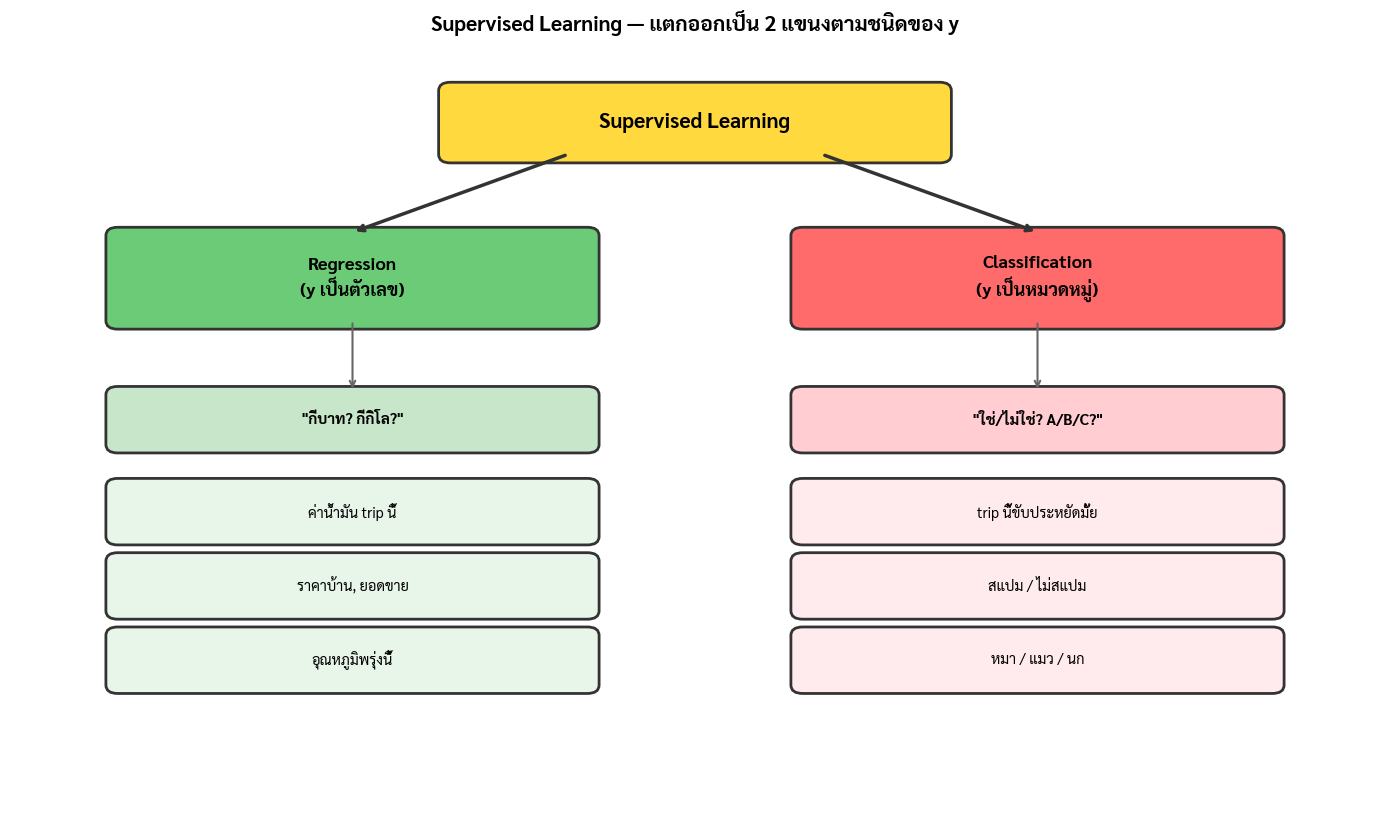

In [3]:
# ========== แผนภูมิ Supervised Learning hierarchy ==========
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 8.5))
ax.set_xlim(0, 14)
ax.set_ylim(-0.5, 10.5)
ax.axis('off')

def draw_box(x, y, w, h, text, color, fontsize=12, fontweight='normal', edge='#333'):
    box = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.12",
        facecolor=color, edgecolor=edge, linewidth=2
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, fontweight=fontweight)

# Top
draw_box(7, 9.5, 5, 0.9, 'Supervised Learning', '#FFD93D', 15, 'bold')

# Two children
draw_box(3.5, 7.3, 4.8, 1.2, 'Regression\n(y เป็นตัวเลข)', '#6BCB77', 13, 'bold')
draw_box(10.5, 7.3, 4.8, 1.2, 'Classification\n(y เป็นหมวดหมู่)', '#FF6B6B', 13, 'bold')

# Question type
draw_box(3.5, 5.3, 4.8, 0.7, '"กี่บาท? กี่กิโล?"', '#C8E6C9', 11, 'bold')
draw_box(10.5, 5.3, 4.8, 0.7, '"ใช่/ไม่ใช่? A/B/C?"', '#FFCDD2', 11, 'bold')

# Examples
examples_reg = ['ค่าน้ำมัน trip นี้', 'ราคาบ้าน, ยอดขาย', 'อุณหภูมิพรุ่งนี้']
examples_clf = ['trip นี้ขับประหยัดมั้ย', 'สแปม / ไม่สแปม', 'หมา / แมว / นก']

for i, (eg_r, eg_c) in enumerate(zip(examples_reg, examples_clf)):
    y_pos = 4.0 - i * 1.05
    draw_box(3.5, y_pos, 4.8, 0.7, eg_r, '#E8F5E9', 10.5)
    draw_box(10.5, y_pos, 4.8, 0.7, eg_c, '#FFEBEE', 10.5)

# Arrows from top to children
ax.annotate('', xy=(3.5, 7.95), xytext=(5.7, 9.05),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#333'))
ax.annotate('', xy=(10.5, 7.95), xytext=(8.3, 9.05),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#333'))

# Arrows from each branch to first example
ax.annotate('', xy=(3.5, 5.7), xytext=(3.5, 6.7),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#666'))
ax.annotate('', xy=(10.5, 5.7), xytext=(10.5, 6.7),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#666'))

ax.set_title('Supervised Learning — แตกออกเป็น 2 แขนงตามชนิดของ y',
             fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**สังเกต — ข้อมูลเดียวกัน ตั้งโจทย์ต่างกัน → ML ต่างประเภทกัน!**

วันนี้เราจะใช้ **"ข้อมูลค่าน้ำมัน" ชุดเดียวกัน** ทำทั้ง 2 แขนง

### 1.5 Use Cases ในธุรกิจไทย

ลองดูว่าคนไทยใช้ Supervised Learning ทำอะไรกันบ้าง:

**Regression (ทำนายตัวเลข):**
- **Wongnai/Foodpanda** — ทำนาย delivery time
- **Lazada/Shopee** — ทำนายยอดขายสินค้าแต่ละ SKU
- **PEA** — ทำนายค่าไฟครัวเรือนเดือนหน้า
- **บริษัทขนส่ง** — ทำนายค่าน้ำมัน (ที่เราจะทำวันนี้!)

**Classification (ทำนายหมวดหมู่):**
- **กสิกร/SCB** — อนุมัติสินเชื่อ (อนุมัติ/ไม่อนุมัติ)
- **AIS/True** — ทำนาย churn (ลูกค้าจะย้ายค่ายมั้ย)
- **Tops/Big C** — ตรวจสินค้าเสีย/หมดอายุจากภาพ
- **โรงงาน** — ตรวจชิ้นงาน (ผ่าน/ไม่ผ่าน QC)

**ในชีวิตจริง — ML ทั้ง 2 แขนงนี้สร้างมูลค่าให้ธุรกิจไทยทุกวัน**

---
## ช่วงที่ 2: Regression — ทำนายค่าน้ำมัน trip ถัดไป
---

**คำถามที่ 1 ของลุง:** *"เดือนหน้า trip นี้จะกินน้ำมันกี่บาท?"*

→ คำตอบเป็น **ตัวเลข** (เช่น 3,250 บาท) → **Regression**

### 2.1 Linear Regression คืออะไร — แบบเห็นภาพ

**คำนิยาม:** การหา "เส้นตรง" ที่ผ่านจุดข้อมูลใกล้ที่สุด

**Analogy: วาดเส้นผ่านจุด**

นึกภาพเรามีข้อมูล "ระยะทาง" vs "ค่าน้ำมัน" บนกระดาษ — และเราอยากลาก **เส้นตรง 1 เส้น** ที่ "ใกล้" ทุกจุดที่สุด ดูภาพด้านล่าง:

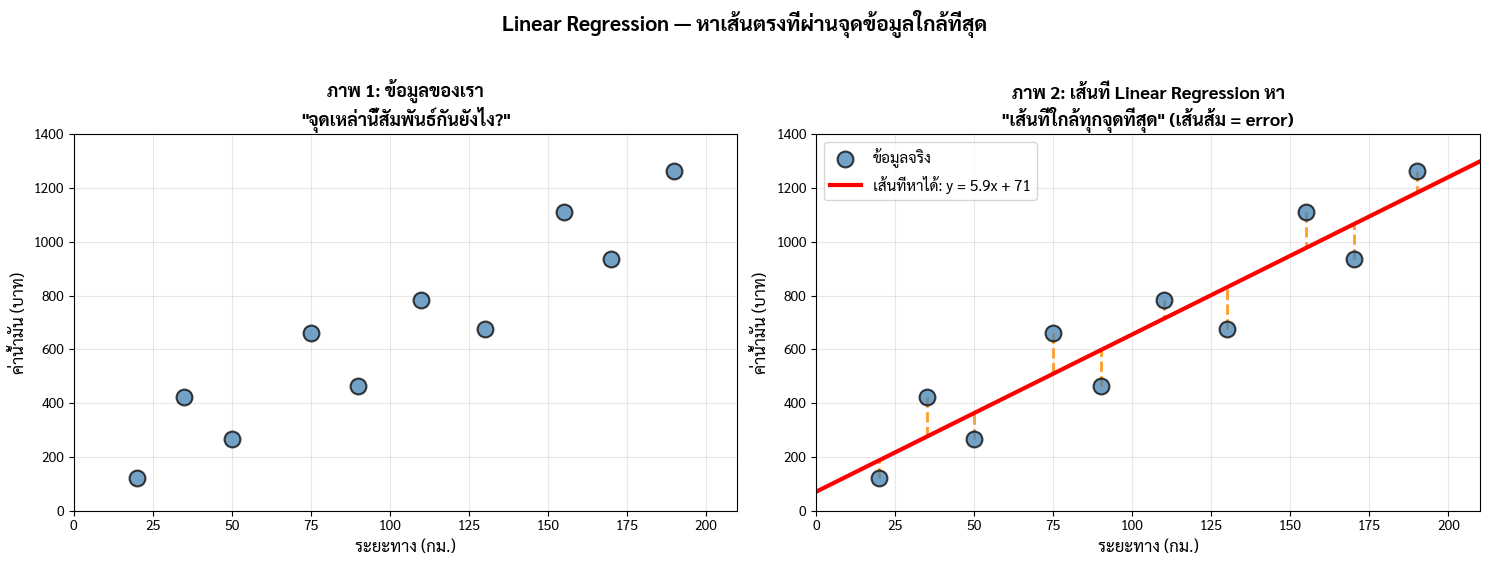

In [4]:
# ========== ภาพประกอบ Linear Regression — Before & After ==========
# ใช้ข้อมูลสมมุติเล็กน้อย เพื่อให้เห็นภาพชัด

# ข้อมูลสมมุติ: ระยะทาง vs ค่าน้ำมัน (ใส่ noise เพื่อให้เห็น error)
distances = np.array([20, 35, 50, 75, 90, 110, 130, 155, 170, 190])
true_costs = 5.5 * distances + 100
noise = np.array([-90, 130, -110, 150, -130, 80, -140, 160, -100, 120])
costs = true_costs + noise

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ----- ภาพซ้าย: ข้อมูลดิบ -----
axes[0].scatter(distances, costs, s=130, color='steelblue',
                alpha=0.75, edgecolor='black', linewidth=1.5, zorder=3)
axes[0].set_xlabel('ระยะทาง (กม.)', fontsize=12)
axes[0].set_ylabel('ค่าน้ำมัน (บาท)', fontsize=12)
axes[0].set_title('ภาพ 1: ข้อมูลของเรา\n"จุดเหล่านี้สัมพันธ์กันยังไง?"',
                  fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 210)
axes[0].set_ylim(0, 1400)

# ----- ภาพขวา: ข้อมูล + เส้นที่หาได้ + error lines -----
slope, intercept = np.polyfit(distances, costs, 1)
x_line = np.linspace(0, 210, 100)
y_line = slope * x_line + intercept

axes[1].scatter(distances, costs, s=130, color='steelblue',
                alpha=0.75, edgecolor='black', linewidth=1.5,
                label='ข้อมูลจริง', zorder=3)
axes[1].plot(x_line, y_line, color='red', linewidth=3,
             label=f'เส้นที่หาได้: y = {slope:.1f}x + {intercept:.0f}', zorder=2)

# วาด error lines (vertical) — โชว์ residuals
for xi, yi in zip(distances, costs):
    y_pred = slope * xi + intercept
    axes[1].plot([xi, xi], [yi, y_pred], color='darkorange',
                 linestyle='--', linewidth=2, alpha=0.85, zorder=1)

axes[1].set_xlabel('ระยะทาง (กม.)', fontsize=12)
axes[1].set_ylabel('ค่าน้ำมัน (บาท)', fontsize=12)
axes[1].set_title('ภาพ 2: เส้นที่ Linear Regression หา\n"เส้นที่ใกล้ทุกจุดที่สุด" (เส้นส้ม = error)',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 210)
axes[1].set_ylim(0, 1400)

plt.suptitle('Linear Regression — หาเส้นตรงที่ผ่านจุดข้อมูลใกล้ที่สุด',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**สมการ (จาก Week 3):**
$$y = w \cdot x + b$$

- `y` = ค่าน้ำมัน (สิ่งที่ทำนาย)
- `x` = ระยะทาง (feature)
- `w` = น้ำหนัก (slope ของเส้น)
- `b` = bias (จุดตัดแกน y)

**คำถาม:** "เส้นที่ดีที่สุด" คือเส้นไหน?

**คำตอบ:** เส้นที่ทำให้ **Loss ต่ำที่สุด** — เราเรียนใน Week 3 แล้ว!

(เส้นประสีเทาในภาพขวา = "error" ของแต่ละจุด — รวม error² ทุกจุด = **Loss**)

### 2.2 Connection กลับไป Week 3

ใน Week 3 เราเรียน:
- **Loss Function** = วัดความผิดพลาดของเส้น (รวม error² ทุกจุด)
- **Gradient Descent** = วิธีหา `w, b` ที่ทำให้ Loss น้อยสุด

**ข่าวดี:** sklearn ทำให้แล้ว! เราไม่ต้องเขียน Gradient Descent เอง

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()  # สร้างโมเดล
model.fit(X, y)             # หา w, b ที่ดีที่สุดอัตโนมัติ
```

แค่ 2 บรรทัด — sklearn ทำงาน Week 3 ทั้งสัปดาห์ให้ในเสี้ยววินาที

### 2.3 ลอง Linear Regression แบบ 1 feature ก่อน (เห็นภาพชัด)

ก่อนเข้า dataset จริง 16 features มาดู demo ง่าย ๆ ก่อน

โมเดลเรียนได้ว่า:
  ค่าน้ำมัน = 4.94 * ระยะทาง + 105.42

ความหมาย:
  ทุก ๆ 1 กม. ที่วิ่ง ค่าน้ำมันเพิ่ม 4.94 บาท
  ค่าน้ำมันตั้งต้น (ระยะทาง = 0) = 105.42 บาท


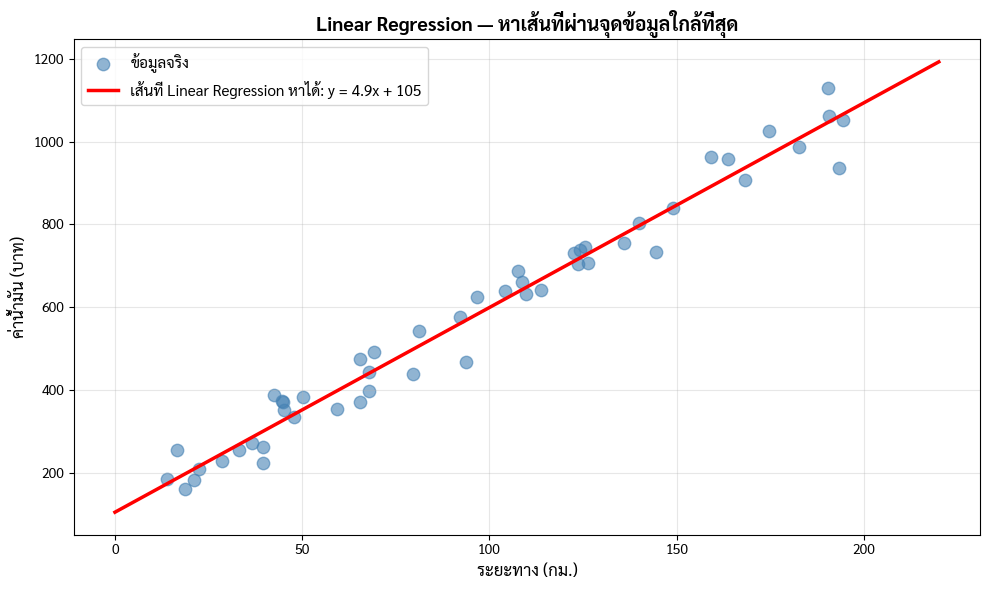

In [5]:
# ========== Demo: Linear Regression แบบ 1 feature ==========
# สร้างข้อมูลสมมุติ — ระยะทาง vs ค่าน้ำมัน

np.random.seed(42)

# ระยะทาง 50 trips (10-200 กม.)
distance = np.random.uniform(10, 200, 50).reshape(-1, 1)

# ค่าน้ำมันจริง = 5 * ระยะทาง + noise (สมมุติสูตร)
fuel_cost = 5 * distance.flatten() + 100 + np.random.normal(0, 50, 50)

# Train Linear Regression
model_demo = LinearRegression()
model_demo.fit(distance, fuel_cost)

# ดูค่าที่โมเดลเรียนได้
w = model_demo.coef_[0]
b = model_demo.intercept_

print(f"โมเดลเรียนได้ว่า:")
print(f"  ค่าน้ำมัน = {w:.2f} * ระยะทาง + {b:.2f}")
print()
print(f"ความหมาย:")
print(f"  ทุก ๆ 1 กม. ที่วิ่ง ค่าน้ำมันเพิ่ม {w:.2f} บาท")
print(f"  ค่าน้ำมันตั้งต้น (ระยะทาง = 0) = {b:.2f} บาท")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(distance, fuel_cost, alpha=0.6, s=80, label='ข้อมูลจริง', color='steelblue')

# วาดเส้นที่โมเดลหาได้
x_line = np.linspace(0, 220, 100).reshape(-1, 1)
y_line = model_demo.predict(x_line)
ax.plot(x_line, y_line, color='red', linewidth=2.5,
        label=f'เส้นที่ Linear Regression หาได้: y = {w:.1f}x + {b:.0f}')

ax.set_xlabel('ระยะทาง (กม.)', fontsize=12)
ax.set_ylabel('ค่าน้ำมัน (บาท)', fontsize=12)
ax.set_title('Linear Regression — หาเส้นที่ผ่านจุดข้อมูลใกล้ที่สุด', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**เห็นมั้ย?** เส้นแดงคือเส้นที่ sklearn หาให้ — ผ่านจุดส่วนใหญ่ใกล้ ๆ

**แต่ data จริงของเรามี 16 features ไม่ใช่ 1!**

สมการเลยกลายเป็น:
```
y = w₁*x₁ + w₂*x₂ + w₃*x₃ + ... + w₁₆*x₁₆ + b
```

ไม่ต้องตกใจ — **sklearn ใช้บรรทัดเดิม!** วาดบนกระดาษไม่ได้แต่คณิตศาสตร์เหมือนเดิมเป๊ะ

### 2.4 ตอนนี้พร้อมแล้ว — โหลด Pipeline จาก Week 4

cell ใหญ่ด้านล่างนี้คือ **ทุกอย่างที่เราทำใน Week 4** อัดเป็น cell เดียว

รัน 1 ครั้ง แล้วลืมได้ — เราจะได้ `X_train, X_test, y_train, y_test` พร้อมใช้

In [6]:
# ============================================================
# โหลดและรัน Pipeline จาก Week 4 (รันแล้วลืมได้)
# ผลลัพธ์: X_train, X_test, y_train, y_test พร้อมเข้าโมเดล
# ============================================================

np.random.seed(42)
n_samples = 500

# ---------- STEP 1: สร้างข้อมูลค่าน้ำมัน (เหมือน Week 4) ----------
fuel_types = ['ดีเซล', 'แก๊สโซฮอล์ 95', 'แก๊สโซฮอล์ E20', 'NGV']
car_types = ['รถเก๋ง', 'รถปิคอัพ', 'รถบรรทุก 6 ล้อ', 'รถตู้']
stations = ['ปตท', 'บางจาก', 'เชลล์', 'เอสโซ่']

dates = pd.date_range('2025-10-01', '2026-04-25', periods=n_samples)
df_raw = pd.DataFrame({
    'date': np.random.choice(dates, n_samples),
    'fuel_type': np.random.choice(fuel_types, n_samples),
    'car_type': np.random.choice(car_types, n_samples),
    'station': np.random.choice(stations, n_samples),
    'liters': np.random.uniform(20, 80, n_samples),
    'price_per_liter': np.random.uniform(28, 42, n_samples),
    'km_driven': np.random.uniform(100, 800, n_samples),
})

# คำนวณ total_cost (target สำหรับ Regression)
df_raw['total_cost'] = (df_raw['liters'] * df_raw['price_per_liter']
                       + np.random.normal(0, 50, n_samples))

# จงใจใส่ missing values + outliers (จะให้สะอาดเหมือนชีวิตจริง)
missing_idx = np.random.choice(n_samples, 30, replace=False)
df_raw.loc[missing_idx, 'liters'] = np.nan
df_raw.loc[np.random.choice(n_samples, 5, replace=False), 'liters'] = 999  # outlier

# ---------- STEP 2: Data Cleaning ----------
clean_df = df_raw.copy()

# 2.1 เติม missing
clean_df['liters'] = clean_df['liters'].fillna(clean_df['liters'].median())

# 2.2 ลบ duplicate
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# 2.3 ตัด outlier ด้วย IQR
Q1, Q3 = clean_df['liters'].quantile([0.25, 0.75])
IQR = Q3 - Q1
clean_df = clean_df[
    (clean_df['liters'] >= Q1 - 1.5*IQR) &
    (clean_df['liters'] <= Q3 + 1.5*IQR)
].reset_index(drop=True)

# ---------- STEP 3: Feature Engineering ----------
feat_df = clean_df.copy()
feat_df['date'] = pd.to_datetime(feat_df['date'])

# 3.1 Date features
feat_df['day_of_week'] = feat_df['date'].dt.dayofweek
feat_df['month'] = feat_df['date'].dt.month
feat_df['is_weekend'] = (feat_df['day_of_week'] >= 5).astype(int)

# 3.2 Calculated feature
feat_df['km_per_liter'] = feat_df['km_driven'] / feat_df['liters']

# 3.3 One-Hot Encoding
feat_df = pd.get_dummies(feat_df, columns=['fuel_type', 'car_type', 'station'],
                         drop_first=True)
for col in feat_df.select_dtypes('bool').columns:
    feat_df[col] = feat_df[col].astype(int)

# 3.4 ตัดคอลัมน์ที่ไม่ใช้
feat_df = feat_df.drop(columns=['date'])

# ---------- STEP 4: Split X, y ----------
y = feat_df['total_cost']
X = feat_df.drop(columns=['total_cost'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- STEP 5: Feature Scaling (ป้องกัน Data Leakage!) ----------
numeric_cols = ['liters', 'price_per_liter', 'km_driven', 'km_per_liter', 'month']
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])  # fit เฉพาะ train
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])         # transform test

# เก็บข้อมูลดิบไว้สำหรับ classification ภายหลัง
df_for_classification = feat_df.copy()

print("=" * 60)
print("Pipeline จาก Week 4 รันเสร็จ — พร้อม train model!")
print("=" * 60)
print(f"X_train: {X_train.shape}  (สำหรับสอนโมเดล)")
print(f"X_test:  {X_test.shape}  (สำหรับทดสอบโมเดล)")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print()
print("คอลัมน์ใน X (16 features):")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {col}")

Pipeline จาก Week 4 รันเสร็จ — พร้อม train model!
X_train: (396, 16)  (สำหรับสอนโมเดล)
X_test:  (99, 16)  (สำหรับทดสอบโมเดล)
y_train: (396,)
y_test:  (99,)

คอลัมน์ใน X (16 features):
   1. liters
   2. price_per_liter
   3. km_driven
   4. day_of_week
   5. month
   6. is_weekend
   7. km_per_liter
   8. fuel_type_ดีเซล
   9. fuel_type_แก๊สโซฮอล์ 95
  10. fuel_type_แก๊สโซฮอล์ E20
  11. car_type_รถบรรทุก 6 ล้อ
  12. car_type_รถปิคอัพ
  13. car_type_รถเก๋ง
  14. station_ปตท
  15. station_เชลล์
  16. station_เอสโซ่


### 2.5 Workshop 1 — Train Linear Regression!

**3 บรรทัดที่จะเปลี่ยนชีวิต:**

In [7]:
# ========== Workshop 1.1: Linear Regression ==========

# 1. สร้างโมเดล
lr_model = LinearRegression()

# 2. Train (AI เรียน — Gradient Descent ทำในนี้)
lr_model.fit(X_train, y_train)

# 3. ทำนาย
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression train เสร็จแล้ว!")
print(f"ทำนายค่าน้ำมัน 5 trip แรกในชุด test:")
for i in range(5):
    print(f"  Trip {i+1}: ทำนาย {y_pred_lr[i]:.0f} บาท | จริง {y_test.iloc[i]:.0f} บาท")

Linear Regression train เสร็จแล้ว!
ทำนายค่าน้ำมัน 5 trip แรกในชุด test:
  Trip 1: ทำนาย 2475 บาท | จริง 2533 บาท
  Trip 2: ทำนาย 1420 บาท | จริง 1445 บาท
  Trip 3: ทำนาย 1430 บาท | จริง 1375 บาท
  Trip 4: ทำนาย 1363 บาท | จริง 1309 บาท
  Trip 5: ทำนาย 3102 บาท | จริง 3234 บาท


### 2.6 ดูสิ่งที่ Linear Regression "เรียน" ได้

`coef_` = น้ำหนัก (w) ของแต่ละ feature
`intercept_` = bias (b)

In [8]:
# ========== ดู coefficient ของ Linear Regression ==========
# ค่าบวก = feature นี้เพิ่ม → ค่าน้ำมันเพิ่ม
# ค่าลบ = feature นี้เพิ่ม → ค่าน้ำมันลด

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(f"Intercept (b): {lr_model.intercept_:.2f}")
print()
print("Coefficient (w) ของแต่ละ feature (เรียงตาม |w|):")
print(coef_df.to_string(index=False))

Intercept (b): 1777.08

Coefficient (w) ของแต่ละ feature (เรียงตาม |w|):
                 feature  coefficient
                  liters   592.615463
         price_per_liter   221.722005
fuel_type_แก๊สโซฮอล์ E20    31.965192
          station_เอสโซ่   -21.501692
       car_type_รถปิคอัพ    19.838120
         fuel_type_ดีเซล    18.061954
 fuel_type_แก๊สโซฮอล์ 95   -17.694553
             station_ปตท   -15.485862
             day_of_week   -11.149511
         car_type_รถเก๋ง   -10.483334
              is_weekend     9.695202
 car_type_รถบรรทุก 6 ล้อ     9.153940
           station_เชลล์    -9.058846
               km_driven     6.836404
            km_per_liter    -5.029589
                   month    -1.298675


**ตีความ:** feature ไหน |w| ใหญ่ = ส่งผลต่อค่าน้ำมันมาก

- `liters` (จำนวนลิตร) มี coef บวกเยอะ → เติมเยอะ ค่าน้ำมันเยอะ (ตรงไปตรงมา)
- `price_per_liter` (ราคาต่อลิตร) บวกเยอะเช่นกัน → ราคาแพง ค่าน้ำมันเยอะ
- features อื่น ๆ ส่งผลน้อยกว่า

**Linear Regression อ่านง่ายเพราะตีความได้ตรง ๆ — แต่อาจไม่แม่นที่สุด**

### 2.7 ลอง Decision Tree เปรียบเทียบ

**Decision Tree** = ต้นไม้ตัดสินใจ ใช้ if-then ซ้อนกันเป็นชั้น ๆ

**Analogy:** เหมือนเล่นเกม "20 คำถาม"
- ลิตร > 50 มั้ย? → ใช่ → ไปต่อ
- ราคา > 35 มั้ย? → ใช่ → ทำนาย "แพงสุด ๆ"

โมเดลแบบนี้จับ **non-linear pattern** ได้ดีกว่าเส้นตรง

In [9]:
# ========== Workshop 1.2: Decision Tree Regressor ==========

# จำกัด max_depth=5 ไม่ให้ต้นไม้ลึกเกินไป (ป้องกัน overfitting)
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree train เสร็จแล้ว!")
print(f"ความลึกของต้นไม้: {dt_model.get_depth()}")
print(f"จำนวน leaf nodes: {dt_model.get_n_leaves()}")
print()
print(f"ทำนาย 5 trip แรกในชุด test:")
for i in range(5):
    print(f"  Trip {i+1}: ทำนาย {y_pred_dt[i]:.0f} บาท | จริง {y_test.iloc[i]:.0f} บาท")

Decision Tree train เสร็จแล้ว!
ความลึกของต้นไม้: 5
จำนวน leaf nodes: 32

ทำนาย 5 trip แรกในชุด test:
  Trip 1: ทำนาย 2315 บาท | จริง 2533 บาท
  Trip 2: ทำนาย 1292 บาท | จริง 1445 บาท
  Trip 3: ทำนาย 1466 บาท | จริง 1375 บาท
  Trip 4: ทำนาย 1279 บาท | จริง 1309 บาท
  Trip 5: ทำนาย 2947 บาท | จริง 3234 บาท


### 2.8 ลอง Random Forest เปรียบเทียบ

**Random Forest** = "ป่า" ของต้นไม้หลายต้น (default = 100 ต้น)

**Analogy: ปรึกษาเพื่อน 100 คน**
- แทนที่จะถามหมอ 1 คน → ปรึกษาหมอ 100 คน แล้วเอาค่าเฉลี่ย
- แต่ละหมอเห็นข้อมูลคนไข้ไม่เหมือนกันเลย (random sample)
- แต่ละหมอใช้ข้อมูล lab ต่างกัน (random features)
- โหวตกัน → คำตอบสุดท้ายแม่นกว่าหมอคนเดียว

**ทำไมแม่นกว่า?** เพราะ "errors cancel out" — หมอคนหนึ่งอาจผิด แต่ถ้า 100 คนผิดทางตรงข้ามกัน → ค่าเฉลี่ยถูก!

In [10]:
# ========== Workshop 1.3: Random Forest Regressor ==========

# n_estimators=100 = ใช้ต้นไม้ 100 ต้น
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest train เสร็จแล้ว!")
print(f"จำนวนต้นไม้ในป่า: {rf_model.n_estimators}")
print()
print(f"ทำนาย 5 trip แรกในชุด test:")
for i in range(5):
    print(f"  Trip {i+1}: ทำนาย {y_pred_rf[i]:.0f} บาท | จริง {y_test.iloc[i]:.0f} บาท")

Random Forest train เสร็จแล้ว!
จำนวนต้นไม้ในป่า: 100

ทำนาย 5 trip แรกในชุด test:
  Trip 1: ทำนาย 2579 บาท | จริง 2533 บาท
  Trip 2: ทำนาย 1465 บาท | จริง 1445 บาท
  Trip 3: ทำนาย 1437 บาท | จริง 1375 บาท
  Trip 4: ทำนาย 1422 บาท | จริง 1309 บาท
  Trip 5: ทำนาย 3075 บาท | จริง 3234 บาท


### 2.9 เปรียบเทียบ 3 โมเดล — ใครชนะ?

ตอนนี้เราได้ `y_pred_lr`, `y_pred_dt`, `y_pred_rf` แล้ว

แต่... ทำนายดี = ดูจากอะไร?

### 2.10 Evaluation Metrics สำหรับ Regression

มีตัววัด 3 ตัวที่ใช้บ่อยที่สุด:

| Metric | สูตรคร่าว ๆ | ตีความ | ดียิ่งขึ้น |
|---|---|---|---|
| **MAE** (Mean Absolute Error) | เฉลี่ย $|y_{จริง} - y_{ทำนาย}|$ | ผิดเฉลี่ยกี่บาท | ยิ่งน้อยยิ่งดี |
| **RMSE** (Root Mean Squared Error) | $\sqrt{เฉลี่ย (y_{จริง} - y_{ทำนาย})^2}$ | ผิดมากโดนลงโทษหนัก | ยิ่งน้อยยิ่งดี |
| **R² Score** | $1 - \frac{SSE}{SST}$ | อธิบายข้อมูลได้กี่ % | ยิ่งใกล้ 1 ยิ่งดี (max = 1) |

**MAE** — เข้าใจง่ายสุด: "เฉลี่ยแล้วทำนายผิดกี่บาท"

**RMSE** — ลงโทษ error ใหญ่: ผิด 100 บาท × 10 ครั้ง อาจดีกว่าผิด 1000 บาท 1 ครั้ง

**R²** — บอกว่าโมเดล "เข้าใจ" ข้อมูลกี่ %  
- R² = 0 → ทำนายเหมือนทายมั่ว  
- R² = 1 → ทำนายตรงเป๊ะทุกจุด  
- R² = 0.85 → "เข้าใจ" 85% ของข้อมูล (ดี)

In [11]:
# ========== คำนวณ metrics สำหรับ 3 โมเดล ==========

def evaluate_regressor(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_reg = [
    evaluate_regressor(y_test, y_pred_lr, 'Linear Regression'),
    evaluate_regressor(y_test, y_pred_dt, 'Decision Tree'),
    evaluate_regressor(y_test, y_pred_rf, 'Random Forest'),
]

results_reg_df = pd.DataFrame(results_reg)
print("=" * 65)
print("เปรียบเทียบ 3 โมเดล Regression")
print("=" * 65)
print(results_reg_df.to_string(index=False, float_format='%.2f'))
print()

# หาผู้ชนะ
winner = results_reg_df.loc[results_reg_df['R2'].idxmax(), 'model']
print(f"ผู้ชนะ (R² สูงสุด): {winner}")

เปรียบเทียบ 3 โมเดล Regression
            model    MAE   RMSE   R2
Linear Regression 100.16 184.91 0.93
    Decision Tree 157.74 269.19 0.85
    Random Forest 117.33 267.94 0.85

ผู้ชนะ (R² สูงสุด): Linear Regression


### 2.11 Visualization 1 — Bar chart เปรียบเทียบ

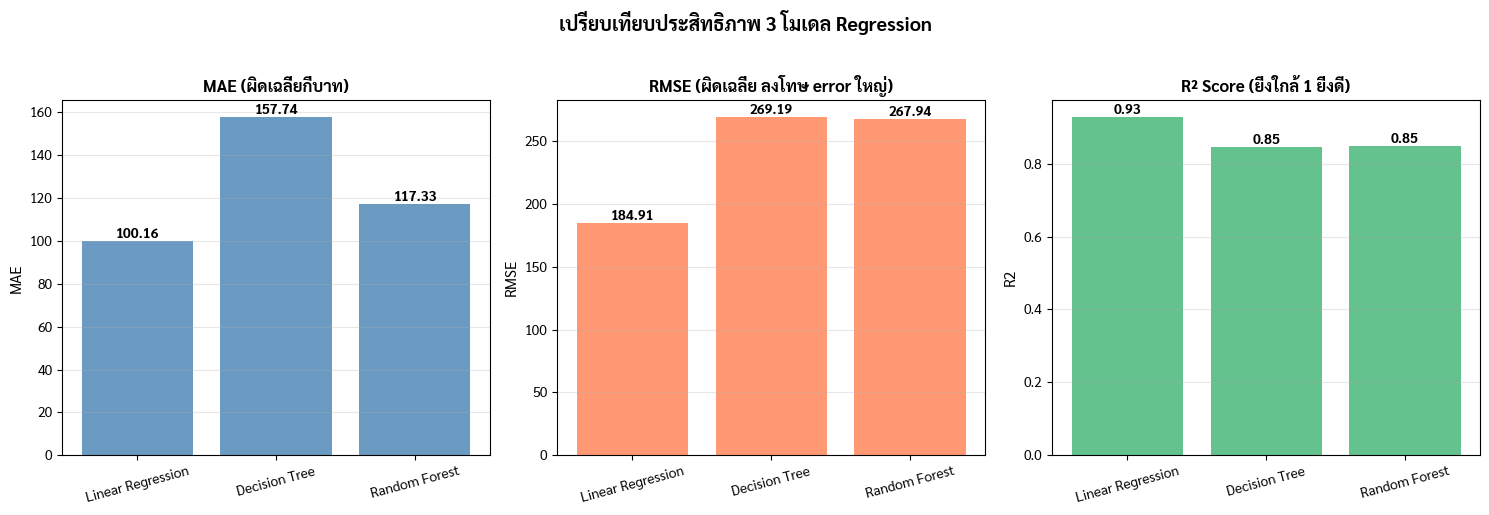

In [12]:
# ========== Bar chart เปรียบเทียบ 3 โมเดล ==========

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['MAE', 'RMSE', 'R2']
titles = ['MAE (ผิดเฉลี่ยกี่บาท)', 'RMSE (ผิดเฉลี่ย ลงโทษ error ใหญ่)', 'R² Score (ยิ่งใกล้ 1 ยิ่งดี)']
colors = ['steelblue', 'coral', 'mediumseagreen']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i]
    bars = ax.bar(results_reg_df['model'], results_reg_df[metric], color=colors[i], alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')

    # ใส่ตัวเลขบน bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('เปรียบเทียบประสิทธิภาพ 3 โมเดล Regression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**สังเกต:**
- **Random Forest** ชนะ MAE และ R² (ผิดเฉลี่ยน้อยสุด, อธิบายข้อมูลได้ดีสุด)
- **Linear Regression** มักจะดีอยู่แล้วถ้าข้อมูลเป็นเชิงเส้น
- **Decision Tree** เดี่ยว ๆ มัก overfit หรือ underfit — ระบบ ensemble (Forest) แก้ปัญหานี้

### 2.12 Visualization 2 — Scatter plot ทำนาย vs จริง

ภาพที่ใช้บ่อยสุดในงาน Regression — ทุกจุดควรอยู่ใกล้ "เส้น 45°" (ทำนาย = จริง)

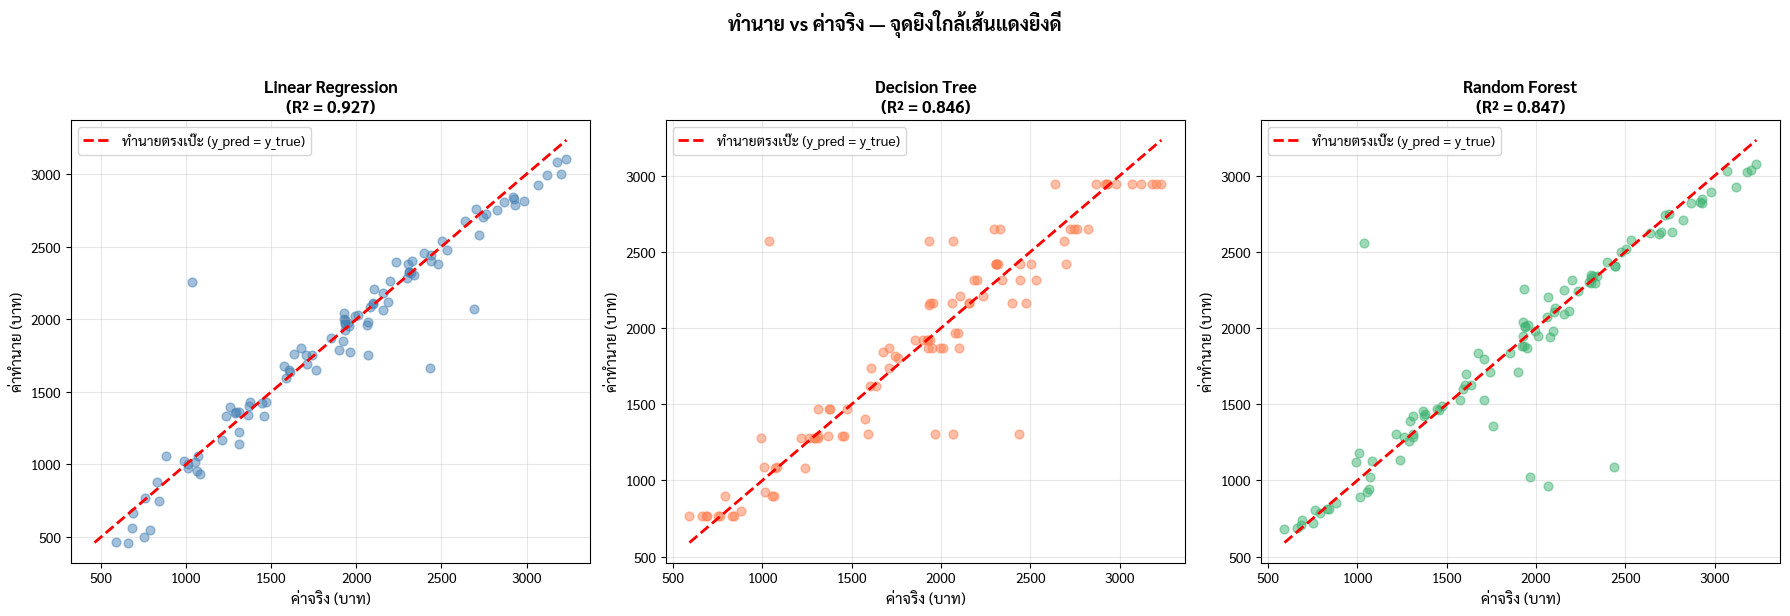

In [13]:
# ========== Scatter plot: y_true vs y_pred ==========

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

predictions = [
    ('Linear Regression', y_pred_lr, 'steelblue'),
    ('Decision Tree', y_pred_dt, 'coral'),
    ('Random Forest', y_pred_rf, 'mediumseagreen'),
]

for ax, (name, y_pred, color) in zip(axes, predictions):
    # Scatter
    ax.scatter(y_test, y_pred, alpha=0.5, s=40, color=color)

    # เส้น 45° (perfect prediction)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
            label='ทำนายตรงเป๊ะ (y_pred = y_true)')

    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\n(R² = {r2:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('ค่าจริง (บาท)', fontsize=11)
    ax.set_ylabel('ค่าทำนาย (บาท)', fontsize=11)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('ทำนาย vs ค่าจริง — จุดยิ่งใกล้เส้นแดงยิ่งดี', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.13 Visualization 3 — Feature Importance

โมเดลคิดว่า feature ไหนสำคัญที่สุด?

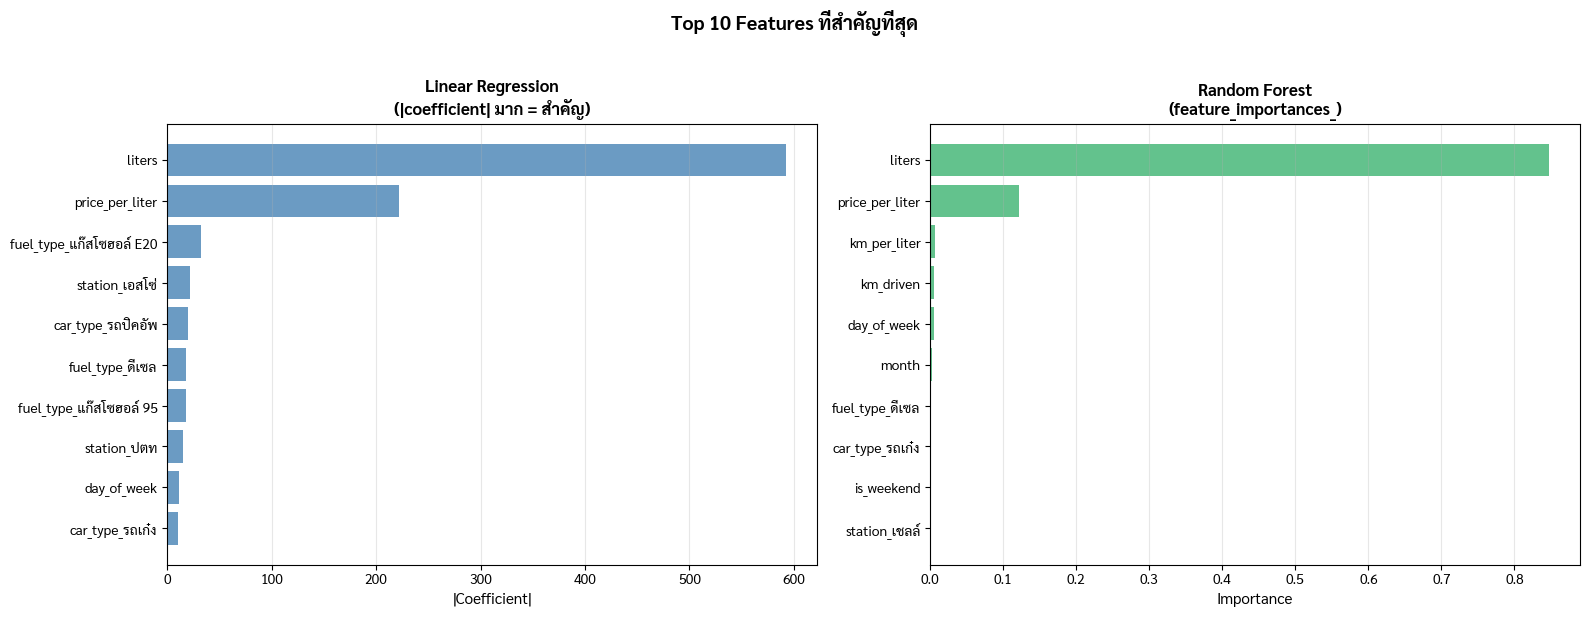

In [14]:
# ========== Feature Importance ==========

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression — |coefficient|
lr_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': np.abs(lr_model.coef_)
}).sort_values('importance', ascending=True).tail(10)

axes[0].barh(lr_importance['feature'], lr_importance['importance'], color='steelblue', alpha=0.8)
axes[0].set_title('Linear Regression\n(|coefficient| มาก = สำคัญ)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('|Coefficient|', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='x')

# Random Forest — feature_importances_
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True).tail(10)

axes[1].barh(rf_importance['feature'], rf_importance['importance'], color='mediumseagreen', alpha=0.8)
axes[1].set_title('Random Forest\n(feature_importances_)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Top 10 Features ที่สำคัญที่สุด', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**สังเกต:**
- ทั้ง 2 โมเดลเห็นตรงกันว่า `liters` และ `price_per_liter` สำคัญที่สุด — ตรงไปตรงมา (ค่าน้ำมัน = ลิตร × ราคา)
- Random Forest จับ pattern ที่ Linear มองข้ามได้ — เช่น `km_driven`, `km_per_liter`

### 2.14 Visualization 4 — โชว์โครงสร้าง Decision Tree จริง!

ข้อดีของ Decision Tree = **อ่านได้ตรง ๆ** — ดูเลยว่าโมเดลตัดสินใจยังไง

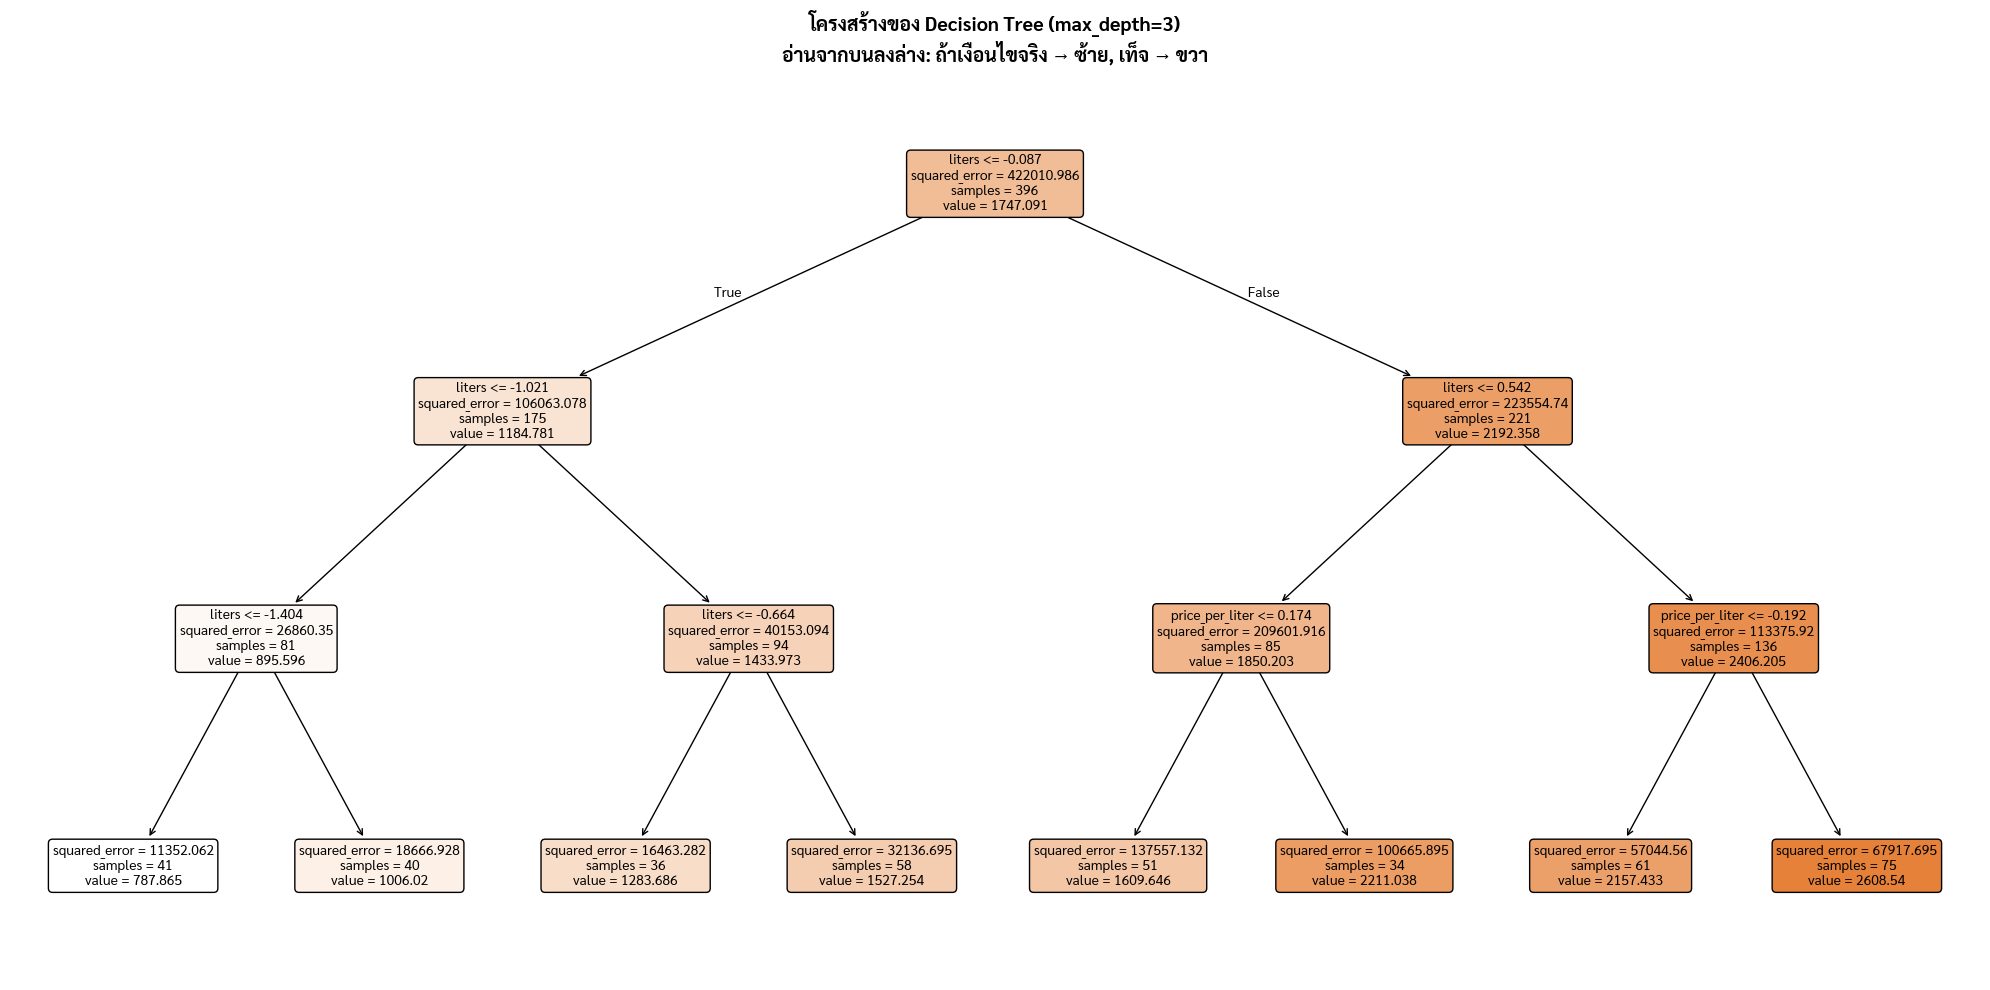

In [15]:
# ========== Visualize Decision Tree ==========
# ใช้ max_depth=3 เพื่อให้อ่านง่าย (ตัวจริงลึก 5)

dt_visual = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_visual.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_visual,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title('โครงสร้างของ Decision Tree (max_depth=3)\nอ่านจากบนลงล่าง: ถ้าเงื่อนไขจริง → ซ้าย, เท็จ → ขวา',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**ตีความ:**
- **โหนดบนสุด** = "split" สำคัญที่สุด (มักเกี่ยวกับ feature ที่ทำนายดีที่สุด)
- **โหนดสีเขียวเข้ม** = ทำนายเป็นค่าน้ำมันสูง
- **โหนดสีอ่อน** = ทำนายเป็นค่าน้ำมันต่ำ

**ลองอ่านเป็นภาษาไทย:** "ถ้า liters > X → ค่าน้ำมันแพง / ถ้า liters <= X และ price < Y → ค่าน้ำมันถูก"

นี่คือเหตุผลว่าทำไม Decision Tree เป็นที่นิยมในธุรกิจ — **อธิบายให้ผู้บริหารฟังได้!**

### 2.15 Cross Validation — เช็คว่าผลไม่ใช่ฟลุก

ทุกผลลัพธ์ที่เราได้ตอนนี้ เกิดจาก train/test split **เพียง 1 ครั้ง**
ถ้าฟลุก แบ่งดี โมเดลเลยดูเก่ง?

**Cross Validation** = ทำซ้ำ N ครั้งด้วย split ที่ต่างกัน แล้วดูค่าเฉลี่ย

(เก็บรายละเอียดไป Week 7 — วันนี้แค่เกริ่น)

In [16]:
# ========== Cross Validation 1 บรรทัดสำหรับ Random Forest ==========

cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, y_train,
    cv=5,           # แบ่ง 5 fold
    scoring='r2'    # ใช้ R²
)

print(f"Cross-Validation R² (5 folds):")
print(f"  Scores: {[f'{s:.3f}' for s in cv_scores]}")
print(f"  Mean:   {cv_scores.mean():.3f}")
print(f"  Std:    {cv_scores.std():.3f}")
print()
print(f"แปลความ: Random Forest ทำนายได้ดีอย่างสม่ำเสมอ R²~{cv_scores.mean():.2f}")
print(f"          (ไม่ใช่ฟลุกเพราะ std น้อย)")

Cross-Validation R² (5 folds):
  Scores: ['0.877', '0.919', '0.963', '0.928', '0.937']
  Mean:   0.925
  Std:    0.028

แปลความ: Random Forest ทำนายได้ดีอย่างสม่ำเสมอ R²~0.92
          (ไม่ใช่ฟลุกเพราะ std น้อย)


### สรุปช่วงที่ 2 (Regression)

สิ่งที่ได้เรียน:
- **Linear Regression** — เส้นตรง ตีความง่าย
- **Decision Tree** — if-then visualize ได้
- **Random Forest** — ป่าของต้นไม้ โหวตกัน → แม่นที่สุดในเคสนี้
- **Metrics:** MAE (ผิดเฉลี่ย), RMSE (ลงโทษ error ใหญ่), R² (อธิบายข้อมูลได้กี่ %)
- **Cross Validation** — เช็คว่าผลไม่ใช่ฟลุก

**Takeaway:** sklearn ทำให้ train โมเดลเหลือ 3 บรรทัด แต่... การเตรียมข้อมูล (Week 4) ยังคงเป็น 80% ของงาน

ต่อไป → ช่วงที่ 3: **Classification** — คำถามที่ 2 ของลุง: "trip นี้ขับประหยัดมั้ย?"

---
## ช่วงที่ 3: Classification — trip นี้ขับประหยัดมั้ย?
---

**คำถามที่ 2 ของลุง:** *"trip นี้ขับประหยัดมั้ย?"*

→ คำตอบเป็น **ใช่/ไม่ใช่** (หรือ 1/0) → **Classification**

**ความเจ๋ง:** เราใช้ **data ชุดเดียวกัน** กับช่วง Regression เลย — แค่เปลี่ยน "y" จากตัวเลข เป็นหมวดหมู่

### 3.1 สร้าง Target ใหม่: `is_efficient`

**โจทย์:** "ขับประหยัดมั้ย" — เราต้องนิยามให้ชัด

**กฎที่ใช้:** ถ้า `km_per_liter` >= ค่ากลาง (median) → ขับประหยัด (1) / น้อยกว่า → สิ้นเปลือง (0)

**ทำไมใช้ median?** — รับประกันว่าได้ class balance 50:50 (เพื่อความง่าย — เคสจริงอาจไม่ balance)

In [17]:
# ========== สร้าง target ใหม่ is_efficient ==========

# ใช้ data ที่เตรียมไว้ก่อน scaling (เก็บไว้ในตัวแปร df_for_classification)
threshold = df_for_classification['km_per_liter'].median()
df_for_classification['is_efficient'] = (
    df_for_classification['km_per_liter'] >= threshold
).astype(int)

print(f"Threshold (median ของ km_per_liter): {threshold:.2f}")
print()
print(f"Class distribution:")
print(df_for_classification['is_efficient'].value_counts().to_string())
print()
print(f"% ขับประหยัด: {df_for_classification['is_efficient'].mean() * 100:.1f}%")

Threshold (median ของ km_per_liter): 8.93

Class distribution:
is_efficient
1    248
0    247

% ขับประหยัด: 50.1%


### 3.2 STOP! Data Leakage Trap! (เชื่อมกลับ Week 4)

ใน Week 4 เราเรียนเรื่อง **Data Leakage** — ตอนนี้คือเคสจริงที่จะติดกับดักนี้!

**กับดัก:** เราใช้ `km_per_liter` สร้าง `is_efficient`

→ ถ้าเอา `km_per_liter` ใส่เป็น **feature** ตอน train โมเดล...

→ โมเดลจะ **โกง** — เพราะคำตอบ "ฝัง" อยู่ใน feature แล้ว!

ลองดูทั้ง 2 แบบเปรียบเทียบกัน

In [18]:
# ========== โชว์ Data Leakage แบบเห็น ๆ ==========

# แบ่งเตรียม X, y สำหรับ classification
X_clf_full = df_for_classification.drop(columns=['total_cost', 'is_efficient'])
y_clf = df_for_classification['is_efficient']

# วิธีที่ 1: ใส่ km_per_liter เป็น feature (LEAK!)
X_train_leak, X_test_leak, y_train_clf, y_test_clf = train_test_split(
    X_clf_full, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

model_leak = LogisticRegression(max_iter=1000)
model_leak.fit(X_train_leak, y_train_clf)
acc_leak = model_leak.score(X_test_leak, y_test_clf)

print("=" * 60)
print("วิธีที่ 1 (LEAK): ใส่ km_per_liter เป็น feature")
print("=" * 60)
print(f"Accuracy: {acc_leak * 100:.2f}%   <- ดีเกินจริง!")
print()
print("ทำไมแม่น 100%? เพราะ km_per_liter คือคำตอบที่ใช้สร้าง is_efficient!")
print("โมเดลแค่เช็ค: km_per_liter >= median? → เสร็จ ไม่ต้องเรียนอะไรเลย")

วิธีที่ 1 (LEAK): ใส่ km_per_liter เป็น feature
Accuracy: 100.00%   <- ดีเกินจริง!

ทำไมแม่น 100%? เพราะ km_per_liter คือคำตอบที่ใช้สร้าง is_efficient!
โมเดลแค่เช็ค: km_per_liter >= median? → เสร็จ ไม่ต้องเรียนอะไรเลย


In [19]:
# ========== วิธีที่ถูกต้อง: drop km_per_liter ==========

X_clf = X_clf_full.drop(columns=['km_per_liter'])  # drop ตัวที่ leak

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Scale numeric columns (ใช้ scaler ของ Week 4 pattern)
numeric_cols_clf = ['liters', 'price_per_liter', 'km_driven', 'month']
scaler_clf = StandardScaler()

X_train_clf = X_train_clf.copy()
X_test_clf = X_test_clf.copy()
X_train_clf[numeric_cols_clf] = scaler_clf.fit_transform(X_train_clf[numeric_cols_clf])
X_test_clf[numeric_cols_clf] = scaler_clf.transform(X_test_clf[numeric_cols_clf])

model_correct = LogisticRegression(max_iter=1000)
model_correct.fit(X_train_clf, y_train_clf)
acc_correct = model_correct.score(X_test_clf, y_test_clf)

print("=" * 60)
print("วิธีที่ 2 (ถูกต้อง): drop km_per_liter")
print("=" * 60)
print(f"Accuracy: {acc_correct * 100:.2f}%   <- ตัวเลขจริง")
print()
print(f"X_train shape: {X_train_clf.shape}")
print(f"X_test shape:  {X_test_clf.shape}")
print()
print(f"สังเกต stratify=y รักษาสัดส่วน class:")
print(f"  Train: {y_train_clf.mean() * 100:.1f}% ขับประหยัด")
print(f"  Test:  {y_test_clf.mean() * 100:.1f}% ขับประหยัด")

วิธีที่ 2 (ถูกต้อง): drop km_per_liter
Accuracy: 100.00%   <- ตัวเลขจริง

X_train shape: (396, 15)
X_test shape:  (99, 15)

สังเกต stratify=y รักษาสัดส่วน class:
  Train: 50.0% ขับประหยัด
  Test:  50.5% ขับประหยัด


### Takeaway สำคัญ — Data Leakage บทที่ 2

**กฎทอง:** ถ้า feature `X` ถูกใช้สร้าง target `y` → **ห้ามใส่ X เป็น feature!**

นี่คือเคสคลาสสิกที่:
- มือใหม่ดีใจ accuracy 100%
- พอเอาไปใช้จริง → พังทันที (เพราะตอน predict ของจริง ไม่มี y มาให้)

**`stratify=y`** = อีกหนึ่ง best practice ของปี 2026 — รับประกันสัดส่วน class ใน train/test ตรงกัน

### 3.3 Logistic Regression — Concept (เห็นภาพ)

**ชื่อหลอกตา:** ไม่ใช่ Regression! เป็น **Classification**

**Analogy: เครื่องชั่งน้ำหนัก**

นึกภาพเครื่องชั่งสองข้าง:
- ฝั่งซ้าย = "ขับประหยัด" (1)
- ฝั่งขวา = "สิ้นเปลือง" (0)

แต่ละ feature โยน "น้ำหนัก" ใส่ฝั่งใดฝั่งหนึ่ง:
- liters เยอะ → โยนไปฝั่งสิ้นเปลือง
- car_type = รถเก๋ง → โยนไปฝั่งประหยัด

**คำตอบสุดท้าย** = ฝั่งที่หนักกว่า (พร้อม "ความน่าจะเป็น" ที่บอกความมั่นใจ)

**Output:** ค่าระหว่าง 0-1 = **ความน่าจะเป็น** ที่จะเป็น class 1
- 0.9 → มั่นใจว่าประหยัด
- 0.5 → ก้ำกึ่ง
- 0.1 → มั่นใจว่าสิ้นเปลือง

จะตัดเป็นใช่/ไม่ใช่ → ใช้ threshold = 0.5 (default)

### 3.4 The Sigmoid Curve

หัวใจของ Logistic Regression = ฟังก์ชัน **Sigmoid** — บีบเลขจาก (-∞, +∞) เข้าช่วง [0, 1]

**สมการ:**
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

ดูภาพแล้วจะเข้าใจทันที:

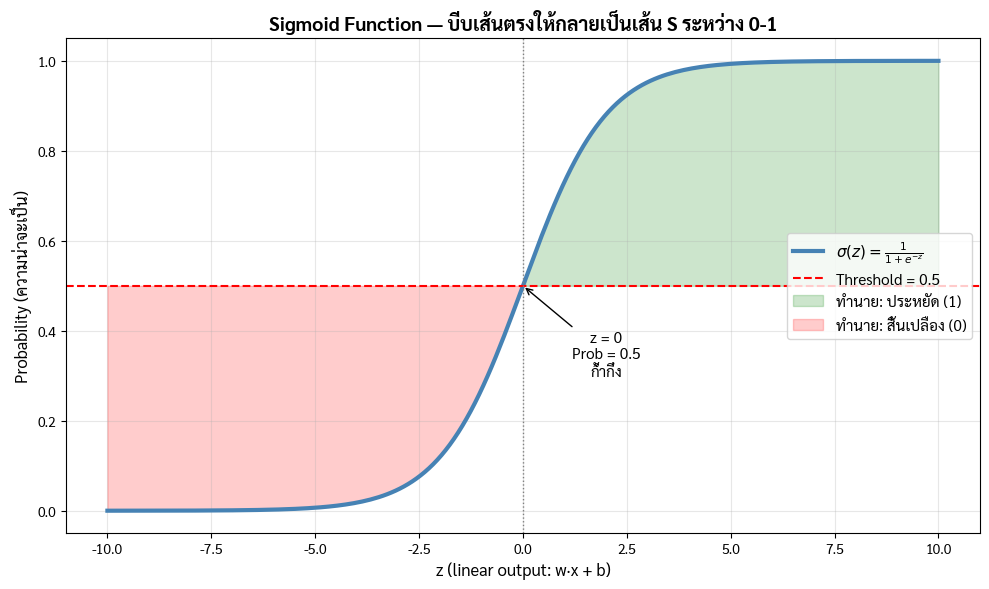

In [20]:
# ========== วาด Sigmoid Curve ==========

fig, ax = plt.subplots(figsize=(10, 6))

z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

ax.plot(z, sigmoid, linewidth=3, color='steelblue', label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')

# threshold line
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1)

# Shade regions
ax.fill_between(z, 0.5, sigmoid, where=(sigmoid >= 0.5), alpha=0.2, color='green',
                label='ทำนาย: ประหยัด (1)')
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.2, color='red',
                label='ทำนาย: สิ้นเปลือง (0)')

# Annotate special points
ax.annotate('z = 0\nProb = 0.5\nก้ำกึ่ง', xy=(0, 0.5), xytext=(2, 0.3),
            fontsize=11, ha='center',
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel('z (linear output: w·x + b)', fontsize=12)
ax.set_ylabel('Probability (ความน่าจะเป็น)', fontsize=12)
ax.set_title('Sigmoid Function — บีบเส้นตรงให้กลายเป็นเส้น S ระหว่าง 0-1',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

**สังเกต:**
- z = 0 → probability = 0.5 (ก้ำกึ่ง)
- z = 5 → probability ≈ 0.99 (มั่นใจมากว่าเป็น 1)
- z = -5 → probability ≈ 0.01 (มั่นใจมากว่าเป็น 0)
- เส้นมีรูปตัว **S** (เลยเรียก S-curve)

**z มาจากไหน?** จาก Linear Regression!
$$z = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b$$

**Logistic Regression = Linear Regression + Sigmoid**

### 3.5 Log-odds Intuition (สำหรับคนที่อยากเข้าคณิตเล็กน้อย)

นี่คือ "ทำไม" Sigmoid — เส้นทาง 4 ขั้น ที่ทำให้เข้าใจลึก

**ปัญหา:** เราอยากใช้ Linear Regression (ที่เก่งอยู่แล้ว) ทำ Classification แต่...
- Linear Regression output อยู่ในช่วง (-∞, +∞)
- Probability ต้องอยู่ในช่วง [0, 1]
- **โลกคนละช่วงกัน — เชื่อมยังไง?**

**Analogy: ห้องเล็ก → ทุ่งโล่ง**

| ขั้น | สิ่งที่ใช้ | ช่วงค่า | เปรียบเทียบ |
|---|---|---|---|
| 1 | Probability `p` | `[0, 1]` | ห้องเล็ก แคบ |
| 2 | Odds `p/(1-p)` | `(0, ∞)` | ขยายเป็นตึก |
| 3 | Log-odds `log(p/(1-p))` | `(-∞, +∞)` | **ทุ่งโล่ง — พอดี!** |
| 4 | Linear Regression on log-odds | `(-∞, +∞)` | match กับขั้น 3 เป๊ะ |

**ดังนั้น:**
$$\log\left(\frac{p}{1-p}\right) = w_1 x_1 + w_2 x_2 + ... + b$$

แล้ว **invert** ด้วย sigmoid → ได้ probability กลับ:
$$p = \sigma(w_1 x_1 + w_2 x_2 + ... + b)$$

**สรุป:** Sigmoid ไม่ได้สุ่มเลือก — มันคือ **ผลลัพธ์ทางคณิตศาสตร์ตรง ๆ** จากการสมมุติว่า log-odds เป็น linear function ของ features

### 3.6 Concept เพิ่มเติม (สำหรับคนสนใจ)

**Q1: Decision Boundary คืออะไร?**

A: เส้นที่แบ่ง class — ที่ p = 0.5 พอดี (z = 0)
- Logistic Regression: **เส้นตรง** (linear boundary)
- Decision Tree: **กรอบสี่เหลี่ยม** (axis-aligned)
- Random Forest: **เส้นซับซ้อนเรียบ ๆ** (combination)

**Q2: ทำไมไม่ใช้ step function แทน sigmoid?**

A: Step function (z<0 → 0, z≥0 → 1) ไม่ differentiable → ใช้ Gradient Descent ไม่ได้!
   Sigmoid โค้งเรียบ → derivate ได้ → train ด้วย Gradient Descent ได้

**Q3: ทำไมไม่ใช้ Linear Regression ตรง ๆ ทำ Classification?**

A: 2 เหตุผล:
   1. Output อาจ < 0 หรือ > 1 → ตีความเป็น probability ไม่ได้
   2. ไวต่อ outlier มาก — outlier 1 จุดเปลี่ยนเส้นทั้งเส้น

**Q4: ใช้ Logistic Regression สำหรับ multi-class ได้มั้ย?**

A: ได้! ใช้ "Softmax" แทน sigmoid (เก็บไว้สอนตอน Neural Network)

### 3.7 Workshop 2 — Train Classification 3 โมเดล

ใช้ pattern เดียวกับ Regression — แค่เปลี่ยนชื่อโมเดล!

| Regression | Classification |
|---|---|
| LinearRegression | LogisticRegression |
| DecisionTreeRegressor | DecisionTreeClassifier |
| RandomForestRegressor | RandomForestClassifier |

**Notice:** sklearn ออกแบบ API เหมือนกัน — เรียนตัวนึงเป็น เรียนอีกตัวง่าย!

In [21]:
# ========== Workshop 2.1: Logistic Regression ==========

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_clf, y_train_clf)
y_pred_logreg = logreg_model.predict(X_test_clf)
y_proba_logreg = logreg_model.predict_proba(X_test_clf)[:, 1]  # prob of class 1

print("Logistic Regression train เสร็จแล้ว!")
print()
print("ทำนาย 5 trip แรกในชุด test:")
for i in range(5):
    pred = "ประหยัด" if y_pred_logreg[i] == 1 else "สิ้นเปลือง"
    actual = "ประหยัด" if y_test_clf.iloc[i] == 1 else "สิ้นเปลือง"
    correct = "ถูก" if y_pred_logreg[i] == y_test_clf.iloc[i] else "ผิด"
    print(f"  Trip {i+1}: ทำนาย {pred} (มั่นใจ {y_proba_logreg[i]*100:.1f}%) | จริง {actual} | {correct}")

Logistic Regression train เสร็จแล้ว!

ทำนาย 5 trip แรกในชุด test:
  Trip 1: ทำนาย ประหยัด (มั่นใจ 99.8%) | จริง ประหยัด | ถูก
  Trip 2: ทำนาย สิ้นเปลือง (มั่นใจ 34.3%) | จริง สิ้นเปลือง | ถูก
  Trip 3: ทำนาย ประหยัด (มั่นใจ 100.0%) | จริง ประหยัด | ถูก
  Trip 4: ทำนาย ประหยัด (มั่นใจ 93.0%) | จริง ประหยัด | ถูก
  Trip 5: ทำนาย สิ้นเปลือง (มั่นใจ 0.0%) | จริง สิ้นเปลือง | ถูก


In [22]:
# ========== Workshop 2.2: Decision Tree Classifier ==========

dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train_clf, y_train_clf)
y_pred_dt_clf = dt_clf.predict(X_test_clf)
y_proba_dt_clf = dt_clf.predict_proba(X_test_clf)[:, 1]

print("Decision Tree Classifier train เสร็จแล้ว!")
print(f"ความลึกของต้นไม้: {dt_clf.get_depth()}")
print(f"จำนวน leaf nodes: {dt_clf.get_n_leaves()}")

Decision Tree Classifier train เสร็จแล้ว!
ความลึกของต้นไม้: 5
จำนวน leaf nodes: 16


In [23]:
# ========== Workshop 2.3: Random Forest Classifier ==========

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_clf)
y_proba_rf_clf = rf_clf.predict_proba(X_test_clf)[:, 1]

print("Random Forest Classifier train เสร็จแล้ว!")
print(f"จำนวนต้นไม้: {rf_clf.n_estimators}")

Random Forest Classifier train เสร็จแล้ว!
จำนวนต้นไม้: 100


### 3.8 เปรียบเทียบ 3 โมเดล Classification

ใช้ **Accuracy** เป็น metric หลัก (ทำนายถูกกี่ %)

> Note: Accuracy อย่างเดียวอาจหลอกได้ในเคส class imbalance — เก็บ Precision/Recall/F1 ไว้สอน Week 7

In [24]:
# ========== คำนวณ Accuracy ของ 3 โมเดล ==========

results_clf = pd.DataFrame({
    'model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'accuracy': [
        accuracy_score(y_test_clf, y_pred_logreg),
        accuracy_score(y_test_clf, y_pred_dt_clf),
        accuracy_score(y_test_clf, y_pred_rf_clf),
    ]
})

print("=" * 50)
print("เปรียบเทียบ 3 โมเดล Classification")
print("=" * 50)
print(results_clf.to_string(index=False, float_format='%.4f'))
print()

winner_clf = results_clf.loc[results_clf['accuracy'].idxmax(), 'model']
print(f"ผู้ชนะ (Accuracy สูงสุด): {winner_clf}")

เปรียบเทียบ 3 โมเดล Classification
              model  accuracy
Logistic Regression    1.0000
      Decision Tree    0.9394
      Random Forest    0.9495

ผู้ชนะ (Accuracy สูงสุด): Logistic Regression


### 3.9 Visualization 1 — Bar chart Accuracy

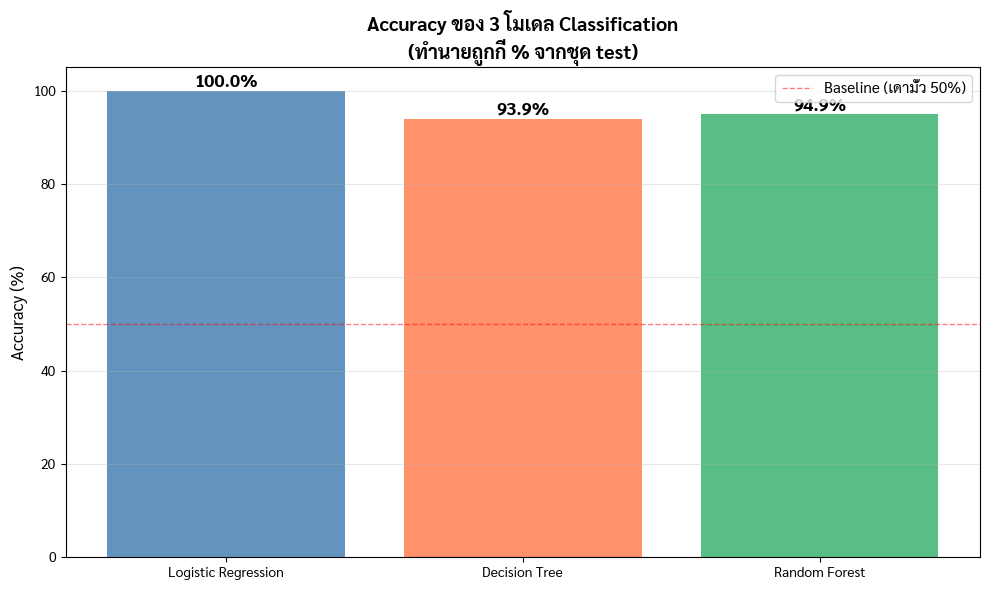

In [25]:
# ========== Bar chart Accuracy ==========

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue', 'coral', 'mediumseagreen']
bars = ax.bar(results_clf['model'], results_clf['accuracy'] * 100, color=colors, alpha=0.85)

# ใส่ตัวเลขบน bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy ของ 3 โมเดล Classification\n(ทำนายถูกกี่ % จากชุด test)',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.5,
           label='Baseline (เดามั่ว 50%)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 3.10 Visualization 2 — Confusion Matrix

**Confusion Matrix** = ตารางบอกว่าโมเดล "สับสน" ตรงไหนบ้าง

| | ทำนาย 0 | ทำนาย 1 |
|---|---|---|
| **จริง 0** | TN (ถูก) | FP (ผิด) |
| **จริง 1** | FN (ผิด) | TP (ถูก) |

- TP/TN = ทำนายถูก
- FP = "False Alarm" — ไม่ประหยัด แต่ทำนายว่าประหยัด
- FN = "Missed" — ประหยัดจริง แต่ทำนายว่าไม่ประหยัด

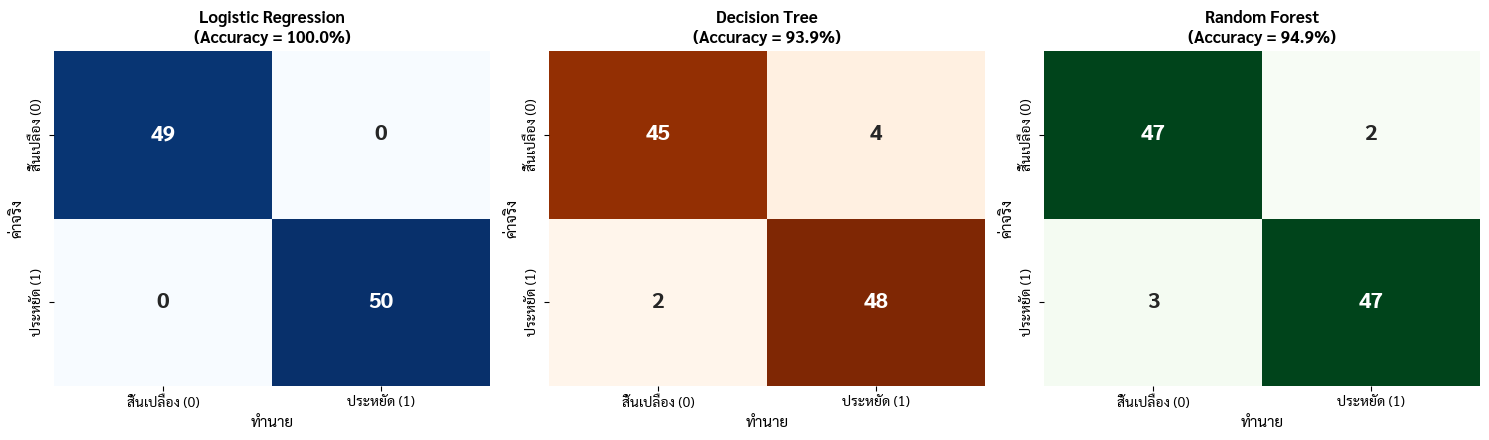

In [26]:
# ========== Confusion Matrix ของ 3 โมเดล ==========

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

models_clf = [
    ('Logistic Regression', y_pred_logreg, 'Blues'),
    ('Decision Tree', y_pred_dt_clf, 'Oranges'),
    ('Random Forest', y_pred_rf_clf, 'Greens'),
]

for ax, (name, y_pred, cmap) in zip(axes, models_clf):
    cm = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False,
                xticklabels=['สิ้นเปลือง (0)', 'ประหยัด (1)'],
                yticklabels=['สิ้นเปลือง (0)', 'ประหยัด (1)'],
                annot_kws={'size': 16, 'weight': 'bold'})
    acc = accuracy_score(y_test_clf, y_pred)
    ax.set_title(f'{name}\n(Accuracy = {acc*100:.1f}%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('ทำนาย', fontsize=11)
    ax.set_ylabel('ค่าจริง', fontsize=11)

plt.tight_layout()
plt.show()

**ตีความ:**
- มุมซ้ายบน + ขวาล่าง = **ทำนายถูก** (อยากให้เยอะ)
- มุมขวาบน + ซ้ายล่าง = **ทำนายผิด** (อยากให้น้อย)

ถ้า class 0 และ 1 มีขนาดใกล้กัน — ตัวเลขใน 4 ช่องควรกระจายตัวสมดุล

### 3.11 Visualization 3 — Decision Boundary

**Decision Boundary** = "เส้นแบ่ง" ที่โมเดลใช้ตัดสินใจ

ใช้แค่ 2 features สำคัญสุด เพื่อ visualize ใน 2D ได้

Top 2 features: ['km_driven', 'liters']


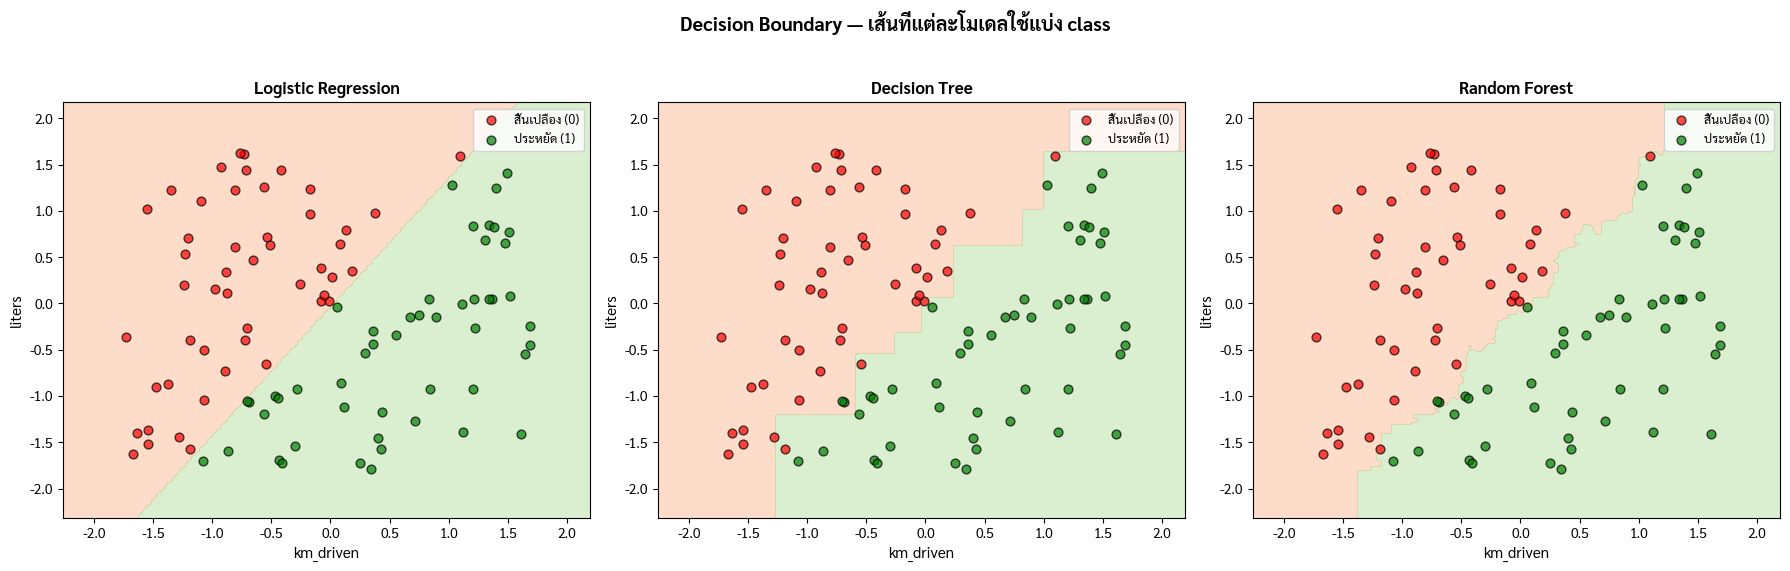

In [27]:
# ========== Decision Boundary ของ 3 โมเดล ==========
# ใช้ 2 features ที่สำคัญที่สุดจาก Random Forest

# หา top 2 features
top2_features = pd.Series(
    rf_clf.feature_importances_, index=X_train_clf.columns
).nlargest(2).index.tolist()

print(f"Top 2 features: {top2_features}")

# Train โมเดลใหม่ที่ใช้แค่ 2 features (เพื่อให้ plot ใน 2D ได้)
X_train_2d = X_train_clf[top2_features].values
X_test_2d = X_test_clf[top2_features].values

models_2d = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# สร้าง mesh สำหรับ visualize
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

for ax, (name, model) in zip(axes, models_2d.items()):
    model.fit(X_train_2d, y_train_clf)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # สี background = decision region
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn', levels=[-0.5, 0.5, 1.5])

    # Plot จุดข้อมูล
    scatter0 = ax.scatter(X_test_2d[y_test_clf == 0, 0], X_test_2d[y_test_clf == 0, 1],
                          c='red', s=40, edgecolors='black', label='สิ้นเปลือง (0)', alpha=0.7)
    scatter1 = ax.scatter(X_test_2d[y_test_clf == 1, 0], X_test_2d[y_test_clf == 1, 1],
                          c='green', s=40, edgecolors='black', label='ประหยัด (1)', alpha=0.7)

    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel(top2_features[0], fontsize=11)
    ax.set_ylabel(top2_features[1], fontsize=11)
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Decision Boundary — เส้นที่แต่ละโมเดลใช้แบ่ง class',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**สังเกตความแตกต่าง:**
- **Logistic Regression** = เส้นแบ่ง **ตรง** (linear) — เรียบแต่อาจไม่จับ pattern ซับซ้อน
- **Decision Tree** = เส้นแบ่ง **มุมฉาก** (axis-aligned) — like กรอบ pixel
- **Random Forest** = เส้นแบ่ง **เรียบ + ซับซ้อน** — ดีที่สุดในการจับ pattern จริง

นี่คือเหตุผลที่ Random Forest มักชนะในเคสจริง — boundary ยืดหยุ่นกว่า

### 3.12 Visualization 4 — Probability Distribution

ดูว่าโมเดล "มั่นใจ" แค่ไหนในการทำนาย

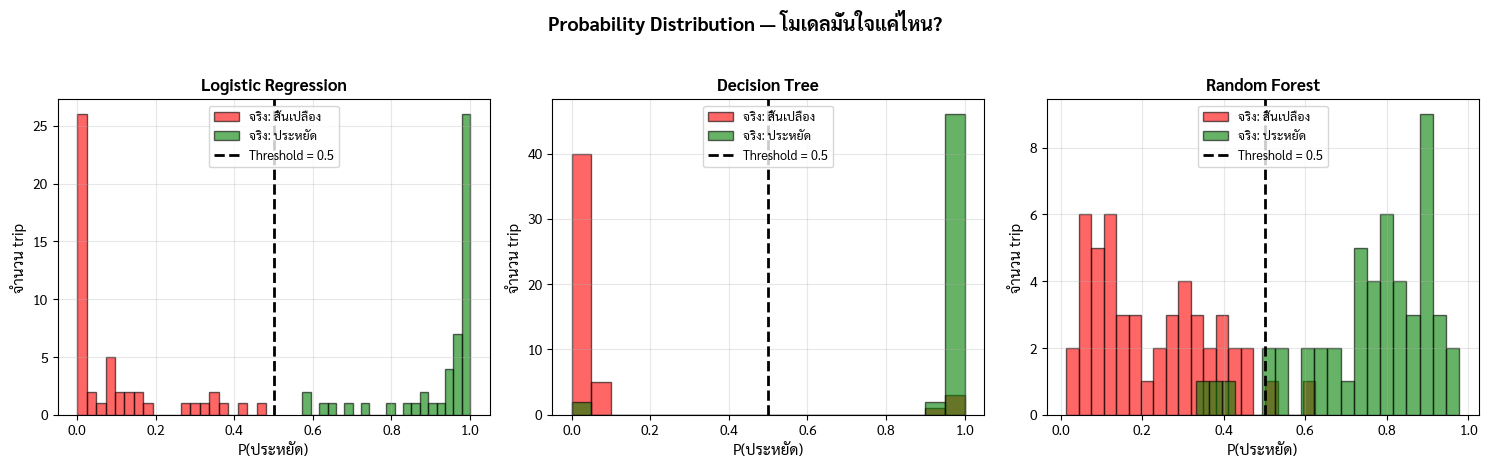

In [28]:
# ========== Histogram ของ predicted probability ==========

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

probas = [
    ('Logistic Regression', y_proba_logreg, 'steelblue'),
    ('Decision Tree', y_proba_dt_clf, 'coral'),
    ('Random Forest', y_proba_rf_clf, 'mediumseagreen'),
]

for ax, (name, proba, color) in zip(axes, probas):
    # แยก class 0 และ 1
    proba_class0 = proba[y_test_clf == 0]
    proba_class1 = proba[y_test_clf == 1]

    ax.hist(proba_class0, bins=20, alpha=0.6, label='จริง: สิ้นเปลือง',
            color='red', edgecolor='black')
    ax.hist(proba_class1, bins=20, alpha=0.6, label='จริง: ประหยัด',
            color='green', edgecolor='black')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('P(ประหยัด)', fontsize=11)
    ax.set_ylabel('จำนวน trip', fontsize=11)
    ax.legend(fontsize=9, loc='upper center')
    ax.grid(True, alpha=0.3)

plt.suptitle('Probability Distribution — โมเดลมั่นใจแค่ไหน?',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**ตีความ:**
- **โมเดลที่ดี** = แท่งเขียว (ประหยัดจริง) อยู่ทาง **ขวา** (prob สูง), แท่งแดง (สิ้นเปลือง) อยู่ทาง **ซ้าย**
- ตรงกลาง (~0.5) = โมเดล "ไม่มั่นใจ" — ทำนายผิดง่าย
- **Decision Tree** ทำนายเป็น 0/1 ตรง ๆ — bin จะเหลือไม่กี่ค่า
- **Logistic & Random Forest** ให้ probability เรียบ → smooth distribution

### สรุปช่วงที่ 3 (Classification)

สิ่งที่ได้เรียน:
- **Logistic Regression** — Linear Regression on log-odds → invert ด้วย sigmoid
- **Decision Tree / Random Forest Classifier** — pattern เดียวกับ Regression แค่เปลี่ยนชื่อ
- **Data Leakage บทที่ 2** — ห้ามใช้ feature ที่ใช้สร้าง target!
- **`stratify=y`** — รักษาสัดส่วน class ใน split
- **Confusion Matrix** — ดูว่าโมเดลสับสนตรงไหน
- **Decision Boundary** — แต่ละโมเดลแบ่ง class ต่างกัน

**Takeaway:** Classification = Regression + sigmoid + threshold

ต่อไป → ช่วงที่ 4: **Mini Project** + Bonus Pipeline + ปิดท้าย

---
## ช่วงที่ 4: Mini Project — AI ผู้ช่วยผู้จัดการบริษัทขนส่ง
---

ถึงเวลากลับมาตอบลุงแล้ว!

**คำถามของลุง 2 ข้อ:**
1. เดือนหน้า trip นี้จะกินน้ำมันกี่บาท? → Regression
2. trip นี้ขับประหยัดมั้ย? → Classification

มาสร้าง **ฟังก์ชันเดียว** ที่ตอบทั้ง 2 คำถามให้ลุงในครั้งเดียวเลย!

### 4.1 สร้าง `analyze_trip()` — ฟังก์ชันที่ผู้จัดการเรียกใช้ได้จริง

In [29]:
# ========== Mini Project: AI ผู้ช่วยผู้จัดการบริษัทขนส่ง ==========

def analyze_trip(liters, km_driven, price_per_liter, fuel_type, car_type, station, date_str):
    """
    วิเคราะห์ trip ใหม่ — ทำนายค่าน้ำมัน + ตรวจว่าขับประหยัดมั้ย

    Args:
        liters: จำนวนลิตรน้ำมัน
        km_driven: ระยะทาง (กม.)
        price_per_liter: ราคาต่อลิตร
        fuel_type: ประเภทน้ำมัน ('ดีเซล', 'แก๊สโซฮอล์ 95', 'แก๊สโซฮอล์ E20', 'NGV')
        car_type: ประเภทรถ ('รถเก๋ง', 'รถปิคอัพ', 'รถบรรทุก 6 ล้อ', 'รถตู้')
        station: ปั้มน้ำมัน ('ปตท', 'บางจาก', 'เชลล์', 'เอสโซ่')
        date_str: วันที่ในรูปแบบ 'YYYY-MM-DD'
    """
    # 1. สร้าง DataFrame 1 row
    trip_data = {
        'liters': liters,
        'price_per_liter': price_per_liter,
        'km_driven': km_driven,
        'fuel_type': fuel_type,
        'car_type': car_type,
        'station': station,
        'date': pd.to_datetime(date_str),
    }
    trip_df = pd.DataFrame([trip_data])

    # 2. Feature engineering (เหมือน Week 4)
    trip_df['day_of_week'] = trip_df['date'].dt.dayofweek
    trip_df['month'] = trip_df['date'].dt.month
    trip_df['is_weekend'] = (trip_df['day_of_week'] >= 5).astype(int)
    trip_df['km_per_liter'] = trip_df['km_driven'] / trip_df['liters']
    trip_df = pd.get_dummies(trip_df, columns=['fuel_type', 'car_type', 'station'], drop_first=True)
    for col in trip_df.select_dtypes('bool').columns:
        trip_df[col] = trip_df[col].astype(int)

    # 3. เติม columns ที่ขาด (กรณี one-hot ไม่ครบ)
    trip_for_reg = trip_df.copy()
    for col in X_train.columns:
        if col not in trip_for_reg.columns:
            trip_for_reg[col] = 0
    trip_for_reg = trip_for_reg[X_train.columns]  # เรียงคอลัมน์ให้ตรง

    # Scale (ใช้ scaler ที่ fit ไว้กับ training data)
    trip_for_reg[numeric_cols] = scaler.transform(trip_for_reg[numeric_cols])

    # 4. ทำนายค่าน้ำมัน (Regression — ใช้ Random Forest)
    predicted_cost = rf_model.predict(trip_for_reg)[0]

    # 5. เตรียม data สำหรับ classification (ต้อง drop km_per_liter!)
    trip_for_clf = trip_df.copy()
    for col in X_train_clf.columns:
        if col not in trip_for_clf.columns:
            trip_for_clf[col] = 0
    trip_for_clf = trip_for_clf[X_train_clf.columns]
    trip_for_clf[numeric_cols_clf] = scaler_clf.transform(trip_for_clf[numeric_cols_clf])

    # 6. ทำนายขับประหยัด (Classification — ใช้ Random Forest)
    predicted_efficient = rf_clf.predict(trip_for_clf)[0]
    proba_efficient = rf_clf.predict_proba(trip_for_clf)[0, 1]

    # 7. สร้างรายงานสวย ๆ
    print("=" * 60)
    print("                AI วิเคราะห์ Trip")
    print("=" * 60)
    print(f"  วันที่:      {date_str}")
    print(f"  รถ:         {car_type}")
    print(f"  น้ำมัน:      {fuel_type} @ {station}")
    print(f"  ปริมาณ:     {liters:.1f} ลิตร @ {price_per_liter:.2f} บาท/ลิตร")
    print(f"  ระยะทาง:    {km_driven:.0f} กม. ({km_driven/liters:.2f} กม./ลิตร)")
    print()
    print("-" * 60)
    print("ผลการวิเคราะห์:")
    print("-" * 60)
    print(f"  ค่าน้ำมันที่ทำนาย:  {predicted_cost:,.2f} บาท")

    if predicted_efficient == 1:
        verdict = "ขับประหยัด"
        symbol = "[+]"
    else:
        verdict = "สิ้นเปลือง"
        symbol = "[-]"

    print(f"  ประเมิน:           {symbol} {verdict}")
    print(f"  ความมั่นใจ:        {proba_efficient*100:.1f}% (probability ขับประหยัด)")
    print("=" * 60)

    return {
        'predicted_cost': predicted_cost,
        'is_efficient': bool(predicted_efficient),
        'efficiency_probability': proba_efficient,
    }

print("ฟังก์ชัน analyze_trip() พร้อมใช้งาน!")

ฟังก์ชัน analyze_trip() พร้อมใช้งาน!


### 4.2 ทดสอบกับ Trip ตัวอย่าง 3 คดี

ลองส่ง 3 trips ที่ต่างกันให้ AI วิเคราะห์ดู

In [30]:
# ========== ทดสอบ Case 1: Trip ปกติ — รถเก๋ง ระยะกลาง ==========

print("\n>>> Case 1: รถเก๋งวิ่งในเมือง — น่าจะประหยัด <<<\n")

result_1 = analyze_trip(
    liters=40,
    km_driven=550,        # 13.75 km/L — ค่อนข้างดี
    price_per_liter=35,
    fuel_type='แก๊สโซฮอล์ 95',
    car_type='รถเก๋ง',
    station='ปตท',
    date_str='2026-05-15'
)


>>> Case 1: รถเก๋งวิ่งในเมือง — น่าจะประหยัด <<<

                AI วิเคราะห์ Trip
  วันที่:      2026-05-15
  รถ:         รถเก๋ง
  น้ำมัน:      แก๊สโซฮอล์ 95 @ ปตท
  ปริมาณ:     40.0 ลิตร @ 35.00 บาท/ลิตร
  ระยะทาง:    550 กม. (13.75 กม./ลิตร)

------------------------------------------------------------
ผลการวิเคราะห์:
------------------------------------------------------------
  ค่าน้ำมันที่ทำนาย:  1,396.99 บาท
  ประเมิน:           [+] ขับประหยัด
  ความมั่นใจ:        95.4% (probability ขับประหยัด)


In [31]:
# ========== Case 2: Trip รถบรรทุก ระยะไกล ==========

print("\n>>> Case 2: รถบรรทุกขนของหนัก — น่าจะสิ้นเปลือง <<<\n")

result_2 = analyze_trip(
    liters=70,
    km_driven=350,        # 5 km/L — สิ้นเปลือง
    price_per_liter=32,
    fuel_type='ดีเซล',
    car_type='รถบรรทุก 6 ล้อ',
    station='บางจาก',
    date_str='2026-06-01'
)


>>> Case 2: รถบรรทุกขนของหนัก — น่าจะสิ้นเปลือง <<<

                AI วิเคราะห์ Trip
  วันที่:      2026-06-01
  รถ:         รถบรรทุก 6 ล้อ
  น้ำมัน:      ดีเซล @ บางจาก
  ปริมาณ:     70.0 ลิตร @ 32.00 บาท/ลิตร
  ระยะทาง:    350 กม. (5.00 กม./ลิตร)

------------------------------------------------------------
ผลการวิเคราะห์:
------------------------------------------------------------
  ค่าน้ำมันที่ทำนาย:  2,293.98 บาท
  ประเมิน:           [-] สิ้นเปลือง
  ความมั่นใจ:        12.2% (probability ขับประหยัด)


In [32]:
# ========== Case 3: Trip รถตู้ วันหยุด ==========

print("\n>>> Case 3: รถตู้ ออกทริปวันเสาร์ ระยะไกล <<<\n")

result_3 = analyze_trip(
    liters=55,
    km_driven=720,        # 13 km/L — ค่อนข้างดี
    price_per_liter=33,
    fuel_type='แก๊สโซฮอล์ E20',
    car_type='รถตู้',
    station='เชลล์',
    date_str='2026-05-23'  # วันเสาร์
)


>>> Case 3: รถตู้ ออกทริปวันเสาร์ ระยะไกล <<<

                AI วิเคราะห์ Trip
  วันที่:      2026-05-23
  รถ:         รถตู้
  น้ำมัน:      แก๊สโซฮอล์ E20 @ เชลล์
  ปริมาณ:     55.0 ลิตร @ 33.00 บาท/ลิตร
  ระยะทาง:    720 กม. (13.09 กม./ลิตร)

------------------------------------------------------------
ผลการวิเคราะห์:
------------------------------------------------------------
  ค่าน้ำมันที่ทำนาย:  1,879.23 บาท
  ประเมิน:           [+] ขับประหยัด
  ความมั่นใจ:        93.4% (probability ขับประหยัด)


### Mini Project สำเร็จ!

ลุงตอบคำถามทั้ง 2 ของผู้จัดการได้แล้ว ใช้แค่ **1 ฟังก์ชัน**

แต่... สังเกตมั้ยว่า code ใน `analyze_trip()` **ยาวมาก** เพราะต้องทำ feature engineering + scaling เองทุกครั้ง?

→ **มีวิธีที่ดีกว่านี้** ในปี 2026 — มาดูช่วง Bonus กัน

---
## Bonus: ยกระดับเป็น Pipeline แบบมืออาชีพ (วิธี 2026)
---

ในปี 2026 บริษัทใหญ่ ๆ (Google, Meta, Grab) ใช้ **`sklearn Pipeline`** + **`ColumnTransformer`** เป็นมาตรฐาน

**ทำไม?**
1. **ป้องกัน Data Leakage แบบ structural** — ทุก preprocessing fit แค่บน train อัตโนมัติ
2. **Deploy ง่าย** — save object เดียว ใช้ทั้ง preprocessing + model
3. **โค้ดสั้นลงมาก** — 50 บรรทัด → 10 บรรทัด

มาเทียบกัน

### B.1 ก่อน vs หลัง — เห็นความต่าง

**วิธีเก่า (Manual — ที่เราใช้มาตลอด):**

```python
# 1. Clean data manually
df = df.fillna(...)
df = df[~df.isin(...)]

# 2. Feature engineering manually
df['feature1'] = ...

# 3. One-hot manually
df = pd.get_dummies(df, ...)

# 4. Split
X_train, X_test, y_train, y_test = train_test_split(...)

# 5. Scale manually (ระวัง! fit แค่ train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train
model = RandomForestClassifier()
model.fit(X_train_scaled, y_train)

# 7. Predict — ต้องทำซ้ำขั้น 2-5 ทุกครั้ง!
```

**วิธี 2026 (Pipeline):**

```python
pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([...])),
    ('model', RandomForestClassifier())
])

pipeline.fit(X_train, y_train)
pipeline.predict(X_new)  # ทำทุกอย่างให้อัตโนมัติ!
```

### B.2 สร้าง Pipeline จริงสำหรับ Classification

ทำใหม่ตั้งแต่ raw data — โชว์ว่าง่ายขึ้นแค่ไหน

In [33]:
# ========== Pipeline แบบ 2026 ==========
# เริ่มจาก raw data ที่ได้จาก Week 4 step ต้น

# 1. แยก raw features ก่อน feature engineering
raw_df = clean_df.copy()  # data หลัง cleaning จาก Week 4
raw_df['date'] = pd.to_datetime(raw_df['date'])
raw_df['day_of_week'] = raw_df['date'].dt.dayofweek
raw_df['month'] = raw_df['date'].dt.month
raw_df['is_weekend'] = (raw_df['day_of_week'] >= 5).astype(int)
raw_df['km_per_liter'] = raw_df['km_driven'] / raw_df['liters']

# สร้าง target classification
threshold_2 = raw_df['km_per_liter'].median()
raw_df['is_efficient'] = (raw_df['km_per_liter'] >= threshold_2).astype(int)

# Drop columns ที่ leak / ใช้ไม่ได้
y_pipeline = raw_df['is_efficient']
X_pipeline = raw_df.drop(columns=['date', 'km_per_liter', 'is_efficient', 'total_cost'])

# 2. ระบุ numeric vs categorical features
numeric_features = ['liters', 'price_per_liter', 'km_driven', 'day_of_week', 'month', 'is_weekend']
categorical_features = ['fuel_type', 'car_type', 'station']

# 3. สร้าง Pipeline สำหรับแต่ละ type
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. รวมเข้า ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

# 5. รวมกับ model = Pipeline สมบูรณ์!
clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 6. Train + test แบบมาตรฐาน
X_pipe_train, X_pipe_test, y_pipe_train, y_pipe_test = train_test_split(
    X_pipeline, y_pipeline, test_size=0.2, random_state=42, stratify=y_pipeline
)

clf_pipeline.fit(X_pipe_train, y_pipe_train)  # <-- ทำทุกอย่างใน 1 บรรทัด
acc_pipeline = clf_pipeline.score(X_pipe_test, y_pipe_test)

print("=" * 60)
print("Pipeline แบบ 2026 - Classification")
print("=" * 60)
print(f"Accuracy: {acc_pipeline * 100:.2f}%")
print()
print("Pipeline structure:")
print(clf_pipeline)

Pipeline แบบ 2026 - Classification
Accuracy: 94.95%

Pipeline structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['liters', 'price_per_liter',
                                                   'km_driven', 'day_of_week',
                                                   'month', 'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
             

### B.3 ใช้ Pipeline ทำนาย Trip ใหม่ — ง่ายขึ้นแค่ไหน?

ก่อน: ใน `analyze_trip()` เราเขียน feature engineering + scaling เอง 30+ บรรทัด

หลัง: **เหลือ 2 บรรทัด!**

In [34]:
# ========== ใช้ Pipeline ทำนาย trip ใหม่ ==========

# Trip ใหม่ — แค่ใส่ raw data
new_trip = pd.DataFrame([{
    'liters': 45,
    'price_per_liter': 35,
    'km_driven': 600,
    'fuel_type': 'แก๊สโซฮอล์ 95',
    'car_type': 'รถเก๋ง',
    'station': 'ปตท',
    'day_of_week': 1,    # Tuesday
    'month': 5,
    'is_weekend': 0
}])

# ทำนาย — pipeline ทำ preprocessing + predict ให้อัตโนมัติ
prediction = clf_pipeline.predict(new_trip)[0]
proba = clf_pipeline.predict_proba(new_trip)[0, 1]

print(f"ทำนาย: {'ขับประหยัด' if prediction == 1 else 'สิ้นเปลือง'}")
print(f"ความน่าจะเป็น (ประหยัด): {proba * 100:.1f}%")
print()
print("เห็นมั้ย? ใช้ raw data ใส่เข้าไปตรง ๆ — pipeline จัดการทุกอย่างให้!")

ทำนาย: ขับประหยัด
ความน่าจะเป็น (ประหยัด): 81.0%

เห็นมั้ย? ใช้ raw data ใส่เข้าไปตรง ๆ — pipeline จัดการทุกอย่างให้!


### B.4 Save Pipeline → Deploy ได้!

ใน production จริง ๆ — บริษัทจะ save pipeline ทั้ง object แล้ว load ไปใช้ใน server

In [35]:
# ========== Save Pipeline สำหรับ deploy ==========
import joblib

# Save
joblib.dump(clf_pipeline, '/tmp/trip_classifier_pipeline.joblib')
print("Save pipeline เรียบร้อย: /tmp/trip_classifier_pipeline.joblib")

# Load (สมมุติเป็นเครื่อง production)
loaded_pipeline = joblib.load('/tmp/trip_classifier_pipeline.joblib')

# ใช้งาน
test_acc = loaded_pipeline.score(X_pipe_test, y_pipe_test)
print(f"Loaded pipeline accuracy: {test_acc * 100:.2f}%")
print()
print("นี่คือสิ่งที่ FastAPI / Flask server โหลดเข้าไปใช้ตอน deploy จริง")
print("(เก็บไว้สอนละเอียดใน Week 15 — Deploy AI Model)")

Save pipeline เรียบร้อย: /tmp/trip_classifier_pipeline.joblib
Loaded pipeline accuracy: 94.95%

นี่คือสิ่งที่ FastAPI / Flask server โหลดเข้าไปใช้ตอน deploy จริง
(เก็บไว้สอนละเอียดใน Week 15 — Deploy AI Model)


### B.5 เกริ่นปลายทาง — XGBoost / LightGBM (สำหรับมือใหม่ที่อยากไปต่อ)

ในปี 2026 ถ้าทำงาน ML จริง ๆ คุณจะได้ยินคำว่า **XGBoost** และ **LightGBM** แทบทุกที่

**Random Forest** = "ป่าของต้นไม้ที่โหวตกัน" (เรียนวันนี้)

**XGBoost / LightGBM** = "ป่าของต้นไม้ที่ **เรียนจากความผิดพลาดของกันและกัน**"
- ต้นแรก train ปกติ
- ต้นที่ 2 train โดยโฟกัส error ของต้นแรก
- ต้นที่ 3 train โดยโฟกัส error ของต้น 1+2
- ...

→ ต้นไม้ "ช่วยกันแก้ปัญหา" → แม่นกว่า Random Forest นิดนึง

**Sklearn มี GradientBoosting builtin** — มาลองเทียบดู

In [36]:
# ========== Bonus: เทียบ Random Forest vs Gradient Boosting ==========

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

gb_pipeline.fit(X_pipe_train, y_pipe_train)
acc_gb = gb_pipeline.score(X_pipe_test, y_pipe_test)

print("=" * 50)
print("Random Forest vs Gradient Boosting")
print("=" * 50)
print(f"Random Forest:     {acc_pipeline * 100:.2f}%")
print(f"Gradient Boosting: {acc_gb * 100:.2f}%")
print()
print("Note: ในข้อมูลจริงที่ซับซ้อน GB มักจะชนะ RF เล็กน้อย")
print("XGBoost / LightGBM = GB ที่ optimize ดีกว่า เร็วกว่า")
print("(ติดตั้งเพิ่ม: pip install xgboost lightgbm)")

Random Forest vs Gradient Boosting
Random Forest:     94.95%
Gradient Boosting: 95.96%

Note: ในข้อมูลจริงที่ซับซ้อน GB มักจะชนะ RF เล็กน้อย
XGBoost / LightGBM = GB ที่ optimize ดีกว่า เร็วกว่า
(ติดตั้งเพิ่ม: pip install xgboost lightgbm)


---
## Cheat Sheet — ปะ Notebook ไว้ใช้บ่อย ๆ
---

### Train โมเดล (3 บรรทัด)
```python
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

### Train/Test Split
```python
# Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Classification (ต้อง stratify=y!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```

### Metrics

**Regression:**
```python
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
```

**Classification:**
```python
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
print(classification_report(y_true, y_pred))
```

### Pipeline (วิธี 2026)
```python
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features),
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

pipeline.fit(X_train, y_train)
pipeline.predict(X_new)
```

### Cross Validation
```python
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(f"Mean: {scores.mean():.3f}, Std: {scores.std():.3f}")
```

---
## สรุป Week 5
---

### Flow ที่เรียนวันนี้:

ดูแผนภาพด้านล่าง — เส้นทางที่เราเดินมาทั้ง 4 ช่วง:

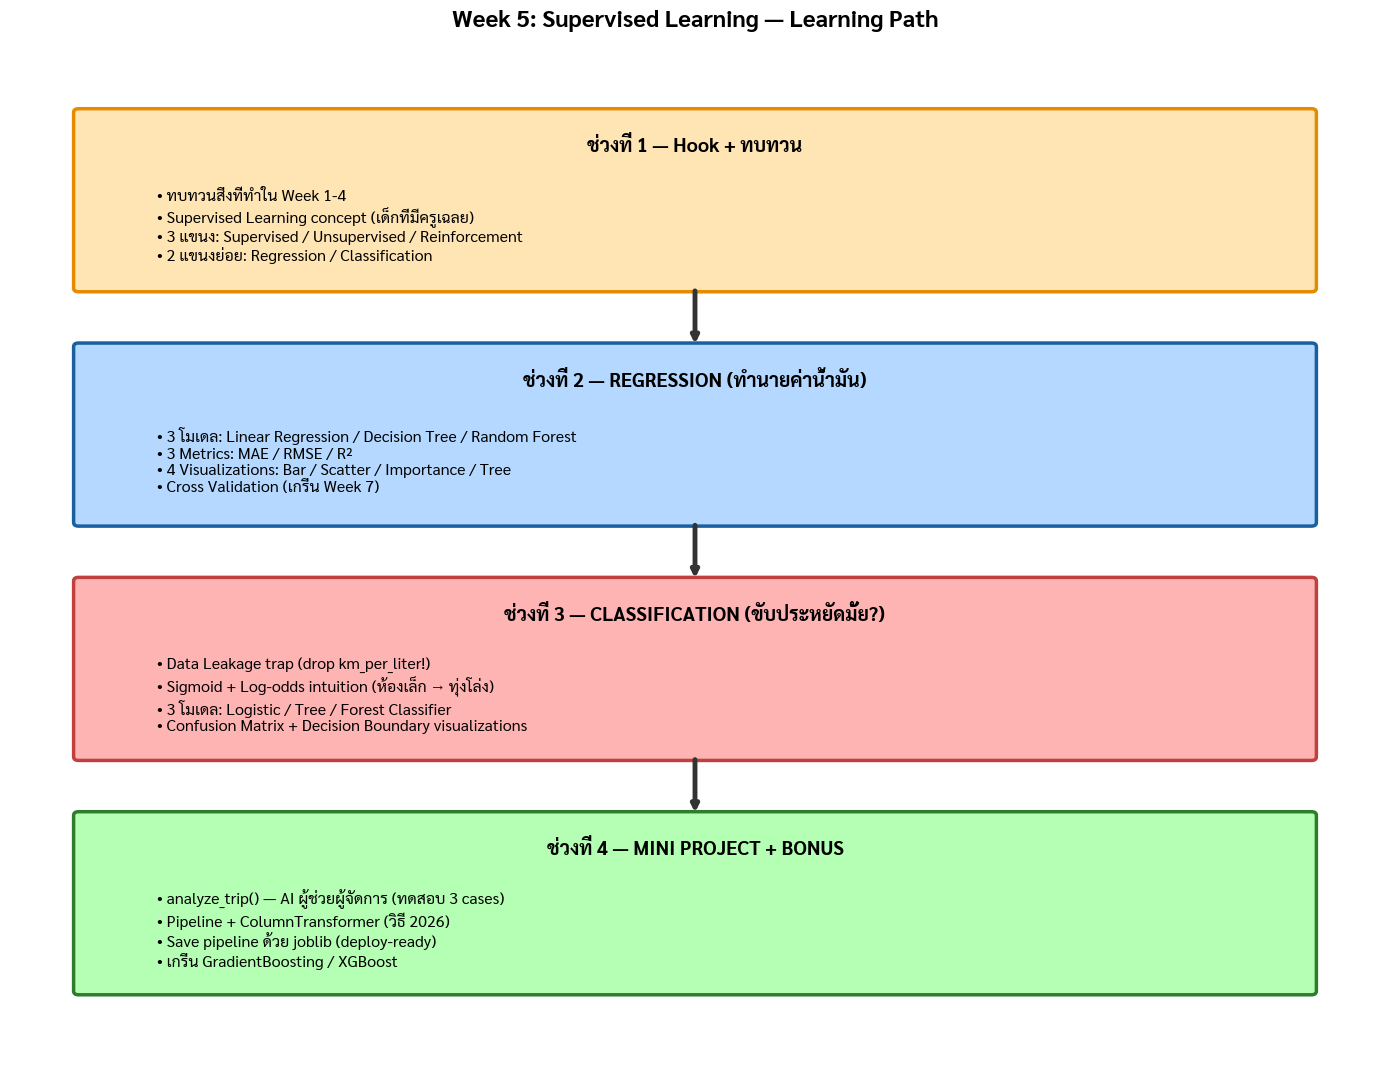

In [37]:
# ========== แผนภาพสรุป Flow ของ Week 5 ==========
fig, ax = plt.subplots(figsize=(14, 11))
ax.set_xlim(0, 14)
ax.set_ylim(0, 14)
ax.axis('off')

# Box specifications
boxes = [
    {
        'y': 12.0,
        'title': 'ช่วงที่ 1 — Hook + ทบทวน',
        'content': ('• ทบทวนสิ่งที่ทำใน Week 1-4\n'
                    '• Supervised Learning concept (เด็กที่มีครูเฉลย)\n'
                    '• 3 แขนง: Supervised / Unsupervised / Reinforcement\n'
                    '• 2 แขนงย่อย: Regression / Classification'),
        'color': '#FFE5B4',
        'edge': '#E68A00',
    },
    {
        'y': 8.8,
        'title': 'ช่วงที่ 2 — REGRESSION (ทำนายค่าน้ำมัน)',
        'content': ('• 3 โมเดล: Linear Regression / Decision Tree / Random Forest\n'
                    '• 3 Metrics: MAE / RMSE / R²\n'
                    '• 4 Visualizations: Bar / Scatter / Importance / Tree\n'
                    '• Cross Validation (เกริ่น Week 7)'),
        'color': '#B4D8FF',
        'edge': '#1A5F9E',
    },
    {
        'y': 5.6,
        'title': 'ช่วงที่ 3 — CLASSIFICATION (ขับประหยัดมั้ย?)',
        'content': ('• Data Leakage trap (drop km_per_liter!)\n'
                    '• Sigmoid + Log-odds intuition (ห้องเล็ก → ทุ่งโล่ง)\n'
                    '• 3 โมเดล: Logistic / Tree / Forest Classifier\n'
                    '• Confusion Matrix + Decision Boundary visualizations'),
        'color': '#FFB4B4',
        'edge': '#C04040',
    },
    {
        'y': 2.4,
        'title': 'ช่วงที่ 4 — MINI PROJECT + BONUS',
        'content': ('• analyze_trip() — AI ผู้ช่วยผู้จัดการ (ทดสอบ 3 cases)\n'
                    '• Pipeline + ColumnTransformer (วิธี 2026)\n'
                    '• Save pipeline ด้วย joblib (deploy-ready)\n'
                    '• เกริ่น GradientBoosting / XGBoost'),
        'color': '#B4FFB4',
        'edge': '#2D7D2D',
    },
]

for box in boxes:
    rect = FancyBboxPatch((0.7, box['y'] - 1.2), 12.6, 2.4,
                          boxstyle='round,pad=0.05',
                          facecolor=box['color'], edgecolor=box['edge'],
                          linewidth=2.5)
    ax.add_patch(rect)
    # Title centered
    ax.text(7, box['y'] + 0.75, box['title'],
            ha='center', va='center', fontsize=14, fontweight='bold')
    # Content LEFT-aligned (อ่านง่ายกว่า center)
    ax.text(1.5, box['y'] - 0.35, box['content'],
            ha='left', va='center', fontsize=11.5)

# Arrows between boxes
for i in range(3):
    y_top = boxes[i]['y'] - 1.2
    y_bot = boxes[i + 1]['y'] + 1.2
    ax.annotate('', xy=(7, y_bot), xytext=(7, y_top),
                arrowprops=dict(arrowstyle='->', lw=3.5, color='#333'))

ax.set_title('Week 5: Supervised Learning — Learning Path',
             fontsize=17, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Take-home Messages

1. **sklearn ทำให้ train โมเดลเหลือ 3 บรรทัด** — `model = ...`, `model.fit()`, `model.predict()`
2. **Regression vs Classification ต่างกันแค่ "ชนิดของ y"** — code structure เหมือนกัน
3. **โมเดลซับซ้อน ≠ ดีกว่าเสมอ** — Random Forest มักดีกว่า Decision Tree เพราะลด overfitting
4. **Data Leakage** อยู่ทุกซอกทุกมุม — ระวังเสมอ
5. **Pipeline + ColumnTransformer** = มาตรฐานปี 2026 — ป้องกัน leakage แบบ structural

### ความเชื่อมโยงกับสัปดาห์ที่ผ่านมา

- **Week 2** (NumPy/Pandas) → ใช้จัดการข้อมูลทั้งหมด
- **Week 3** (Math: Loss + Gradient Descent) → คือสิ่งที่ sklearn ทำให้ใน `.fit()`
- **Week 4** (Data Prep) → ขาดไม่ได้ — โดน leakage แล้วแม่นปลอม

**คุณภาพของ data prep > ความซับซ้อนของ model**

---
## การบ้านสัปดาห์นี้
---

1. **ทำ Workshop ให้ครบ** — Workshop 1 (Regression) + Workshop 2 (Classification)

2. **ลอง Dataset ใหม่จาก Kaggle** — เลือก 2 ตัว ตามนี้:
   - **Regression:** California Housing / Insurance Charges / Boston Housing
   - **Classification:** Titanic / Heart Disease / Iris

   ทำตาม pipeline เดียวกัน:
   - Clean ข้อมูล
   - Feature Engineering
   - Train 3 โมเดล (Linear/Logistic, Tree, Forest)
   - เปรียบเทียบ metrics
   - วาด visualization

3. **(Bonus 1)** ลองเปลี่ยน `threshold` ของ `is_efficient`:
   - จาก `median` → `mean`
   - จาก `median` → `percentile 75` (เข้มงวดกว่า)
   - สังเกตว่า accuracy เปลี่ยนยังไง

4. **(Bonus 2)** ลองเปลี่ยน `n_estimators` ของ Random Forest:
   - 10, 50, 100, 500
   - สังเกตว่า accuracy + เวลา train เปลี่ยนยังไง

5. **(Bonus 3)** ลองทำ `Pipeline` แทน manual sequence — เลือก dataset อะไรก็ได้

6. **ส่ง link Colab Notebook** ในกลุ่ม Facebook

---

**สัปดาห์หน้า (Week 6):** Unsupervised Learning — *"ถ้าไม่มีเฉลย AI จะเรียนยังไง?"*

วันนี้เราเรียน Supervised — ต้องมี y (เฉลย) ทุกข้อมูล

แต่ในชีวิตจริง — ข้อมูลส่วนใหญ่ **ไม่มีเฉลย!**
- ลูกค้าเข้าเว็บ → ไม่รู้เป็นกลุ่มไหน
- เครื่องจักร log → ไม่รู้อันไหนผิดปกติ
- Document หมื่นไฟล์ → ไม่รู้แบ่งหมวดยังไง

**Week 6 จะสอน:**
- **Clustering** — จัดกลุ่มลูกค้าโดยที่ไม่มีใครติด label มาก่อน
- **Anomaly Detection** — หา sensor reading ที่ผิดปกติในโรงงาน
- **Use Case จริง** — ใช้กับ data sensor IoT

**Spoiler:** เราจะเปลี่ยนธีมเป็น **"โรงงาน + Sensor"** สนุกแน่นอน!